In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import pandas as pd

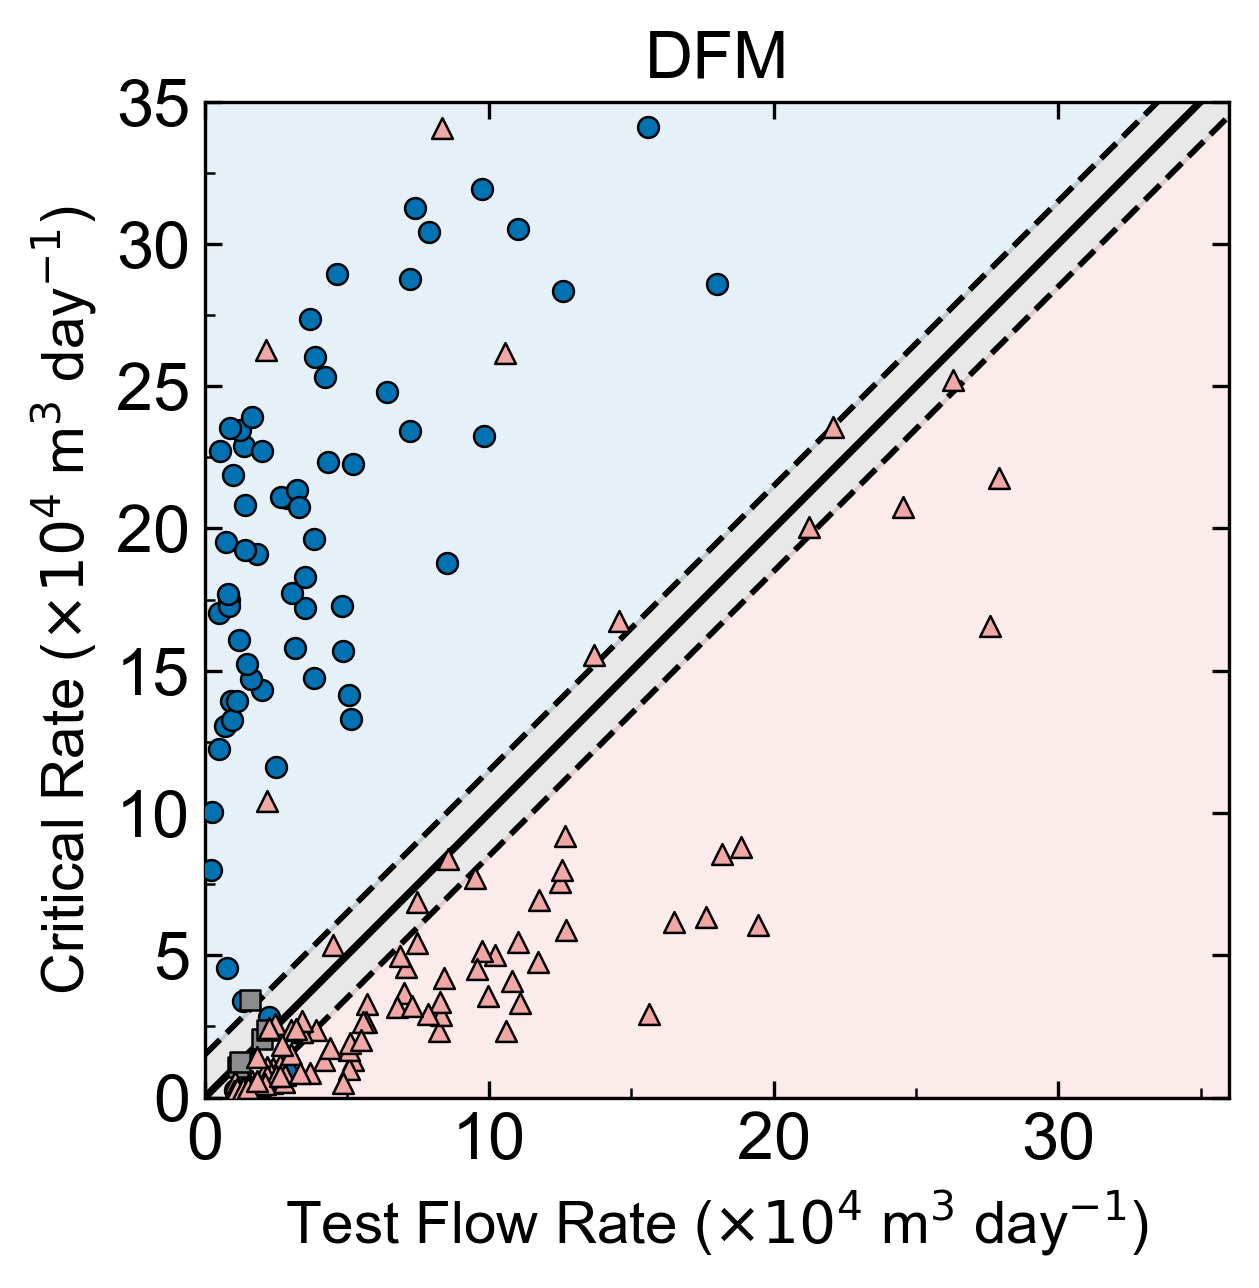

In [ ]:

# -----------------------------
# Global journal-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 16,
    "axes.labelsize": 14,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "mathtext.fontset": "dejavusans",
})
# -----------------------------
# Domain
# -----------------------------
xmin, xmax = 0, 360000
x = np.linspace(xmin, xmax, 600)

# Parallel boundaries about y = x
delta = 15000
upper = x + delta
lower = x - delta

# -----------------------------
# Figure setup (journal aspect)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# -----------------------------
# Regions (print-safe, colorblind-safe)
# -----------------------------

# Unloaded
ax.fill_between(
    x,
    np.clip(upper, xmin, xmax),
    xmax,
    color="#0072B2",
    alpha=0.10,
    label="Loaded",
    zorder=1
)

# Near ILU
ax.fill_between(
    x,
    np.clip(lower, xmin, xmax),
    np.clip(upper, xmin, xmax),
    color="0.55",
    alpha=0.20,
    label="Near L.U",
    zorder=1
)

# Loaded
ax.fill_between(
    x,
    xmin,
    np.clip(lower, xmin, xmax),
    color="#F2A7A7",
    alpha=0.22,
    label="Unloaded",
    zorder=1
)

# -----------------------------
# Boundaries
# -----------------------------
ax.plot(x, x, color="black", linewidth=1.8, zorder=3)
ax.plot(x, upper, linestyle="--", color="black", linewidth=1.4, zorder=3)
ax.plot(x, lower, linestyle="--", color="black", linewidth=1.4, zorder=3)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Test Flow Rate (m$^3$ day$^{-1}$)")
ax.set_ylabel(r"Critical Rate (m$^3$ day$^{-1}$)")

ax.tick_params(length=4, width=0.8, top=True, right=True)
ax.tick_params(which="minor", length=2.5, width=0.6)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# -----------------------------
# Read CSV data
# -----------------------------
# CSV columns:
# Liquid droplet model, Test flow rate, Well status
df = pd.read_csv(r"./compariosn_mix.csv")

# -----------------------------
# Scatter styling by well status
# -----------------------------
status_style = {
    "Loaded":        {"marker": "o", "color": "#0072B2"},
    "Near L.U":   {"marker": "s", "color": "0.55"},
    "Unloaded":      {"marker": "^", "color": "#F2A7A7"},
    
}

# -----------------------------
# Plot data points
# -----------------------------
for status, style in status_style.items():
    subset = df[df["Well status"] == status]
    if subset.empty:
        continue

    ax.scatter(
        subset["Test flow rate"],
        subset["Droplet-Film model"],
        s=25,
        marker=style["marker"],
        facecolor=style["color"],
        edgecolor="black",
        linewidth=0.6,
        label=status,
        zorder=5
    )
    
    ax.set_title(
    "DFM",
    fontsize=16,
    pad=6)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.set_xlabel(r"Test Flow Rate ($\times 10^4$ m$^3$ day$^{-1}$)")
    ax.set_ylabel(r"Critical Rate ($\times 10^4$ m$^3$ day$^{-1}$)")

    ax.set_ylim(0, 350000) #### ENSURE ALL PLOTS HAVE THIS 

#### LEGEND only needed fo rone plot 
# -----------------------------
# Legend (journal style)
# -----------------------------
"""
ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    handlelength=1.8,
    labelspacing=0.4
)
"""

plt.tight_layout()

# -----------------------------
# Save figures
# -----------------------------
plt.savefig("dft_new.pdf")
plt.savefig("dft_new.png")
plt.savefig("dft_new.svg")

plt.show()


# Unsure of the result below... Awwal was referning a different file

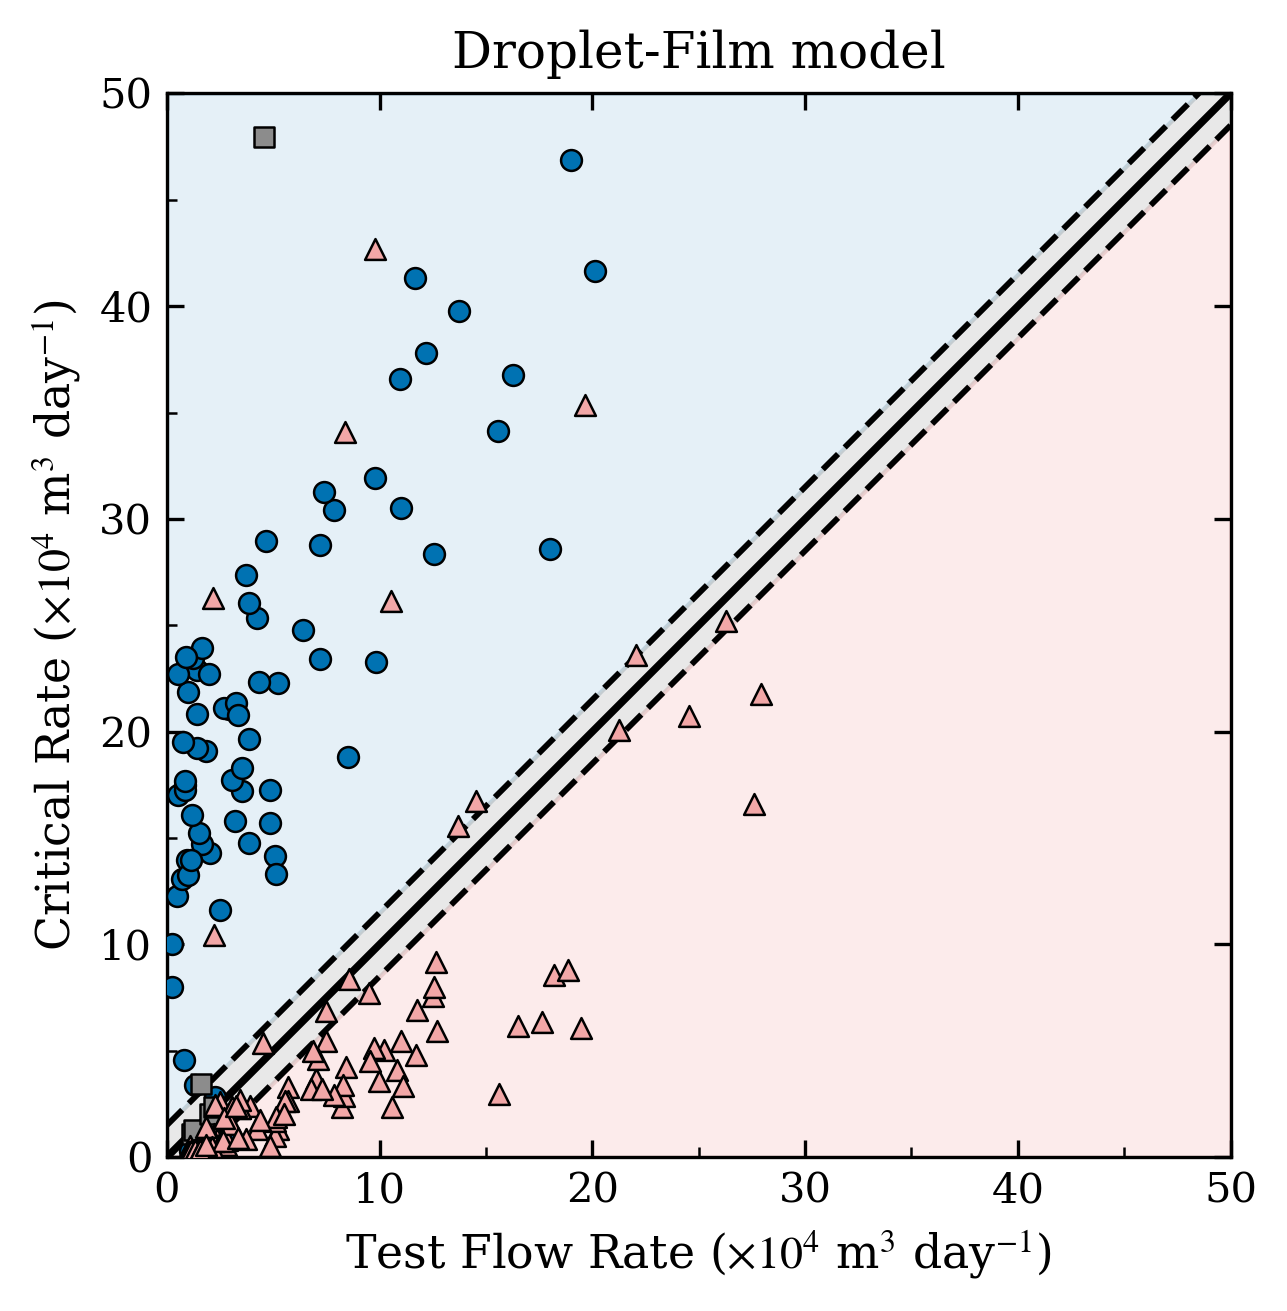

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import pandas as pd

# -----------------------------
# Global journal-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight"
})

# -----------------------------
# Domain
# -----------------------------
xmin, xmax = 0, 500000
x = np.linspace(xmin, xmax, 600)

# Parallel boundaries about y = x
delta = 15000
upper = x + delta
lower = x - delta

# -----------------------------
# Figure setup (journal aspect)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# -----------------------------
# Regions (print-safe, colorblind-safe)
# -----------------------------

# Unloaded
ax.fill_between(
    x,
    np.clip(upper, xmin, xmax),
    xmax,
    color="#0072B2",
    alpha=0.10,
    label="Loaded",
    zorder=1
)

# Near ILU
ax.fill_between(
    x,
    np.clip(lower, xmin, xmax),
    np.clip(upper, xmin, xmax),
    color="0.55",
    alpha=0.20,
    label="Near L.U",
    zorder=1
)

# Loaded
ax.fill_between(
    x,
    xmin,
    np.clip(lower, xmin, xmax),
    color="#F2A7A7",
    alpha=0.22,
    label="Unloaded",
    zorder=1
)

# -----------------------------
# Boundaries
# -----------------------------
ax.plot(x, x, color="black", linewidth=1.8, zorder=3)
ax.plot(x, upper, linestyle="--", color="black", linewidth=1.4, zorder=3)
ax.plot(x, lower, linestyle="--", color="black", linewidth=1.4, zorder=3)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Test Flow Rate (m$^3$ day$^{-1}$)")
ax.set_ylabel(r"Critical Rate (m$^3$ day$^{-1}$)")

ax.tick_params(length=4, width=0.8, top=True, right=True)
ax.tick_params(which="minor", length=2.5, width=0.6)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# -----------------------------
# Read CSV data
# -----------------------------
# CSV columns:
# Liquid droplet model, Test flow rate, Well status
df = pd.read_csv(r"./compariosn_mix.csv")

# -----------------------------
# Scatter styling by well status
# -----------------------------
status_style = {
    "Loaded":        {"marker": "o", "color": "#0072B2"},
    "Near L.U":   {"marker": "s", "color": "0.55"},
    "Unloaded":      {"marker": "^", "color": "#F2A7A7"},
    
}

# -----------------------------
# Plot data points
# -----------------------------
for status, style in status_style.items():
    subset = df[df["Well status"] == status]
    if subset.empty:
        continue

    ax.scatter(
        subset["Test flow rate"],
        subset["Droplet-Film model"],
        s=25,
        marker=style["marker"],
        facecolor=style["color"],
        edgecolor="black",
        linewidth=0.6,
        label=status,
        zorder=5
    )
    
    ax.set_title(
    "Droplet-Film model",
    fontsize=12,
    pad=6)
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.set_xlabel(r"Test Flow Rate ($\times 10^4$ m$^3$ day$^{-1}$)")
    ax.set_ylabel(r"Critical Rate ($\times 10^4$ m$^3$ day$^{-1}$)")


plt.tight_layout()

# -----------------------------
# Save figures
# -----------------------------
plt.savefig("dft_new.pdf")
plt.savefig("dft_new.png")

plt.show()


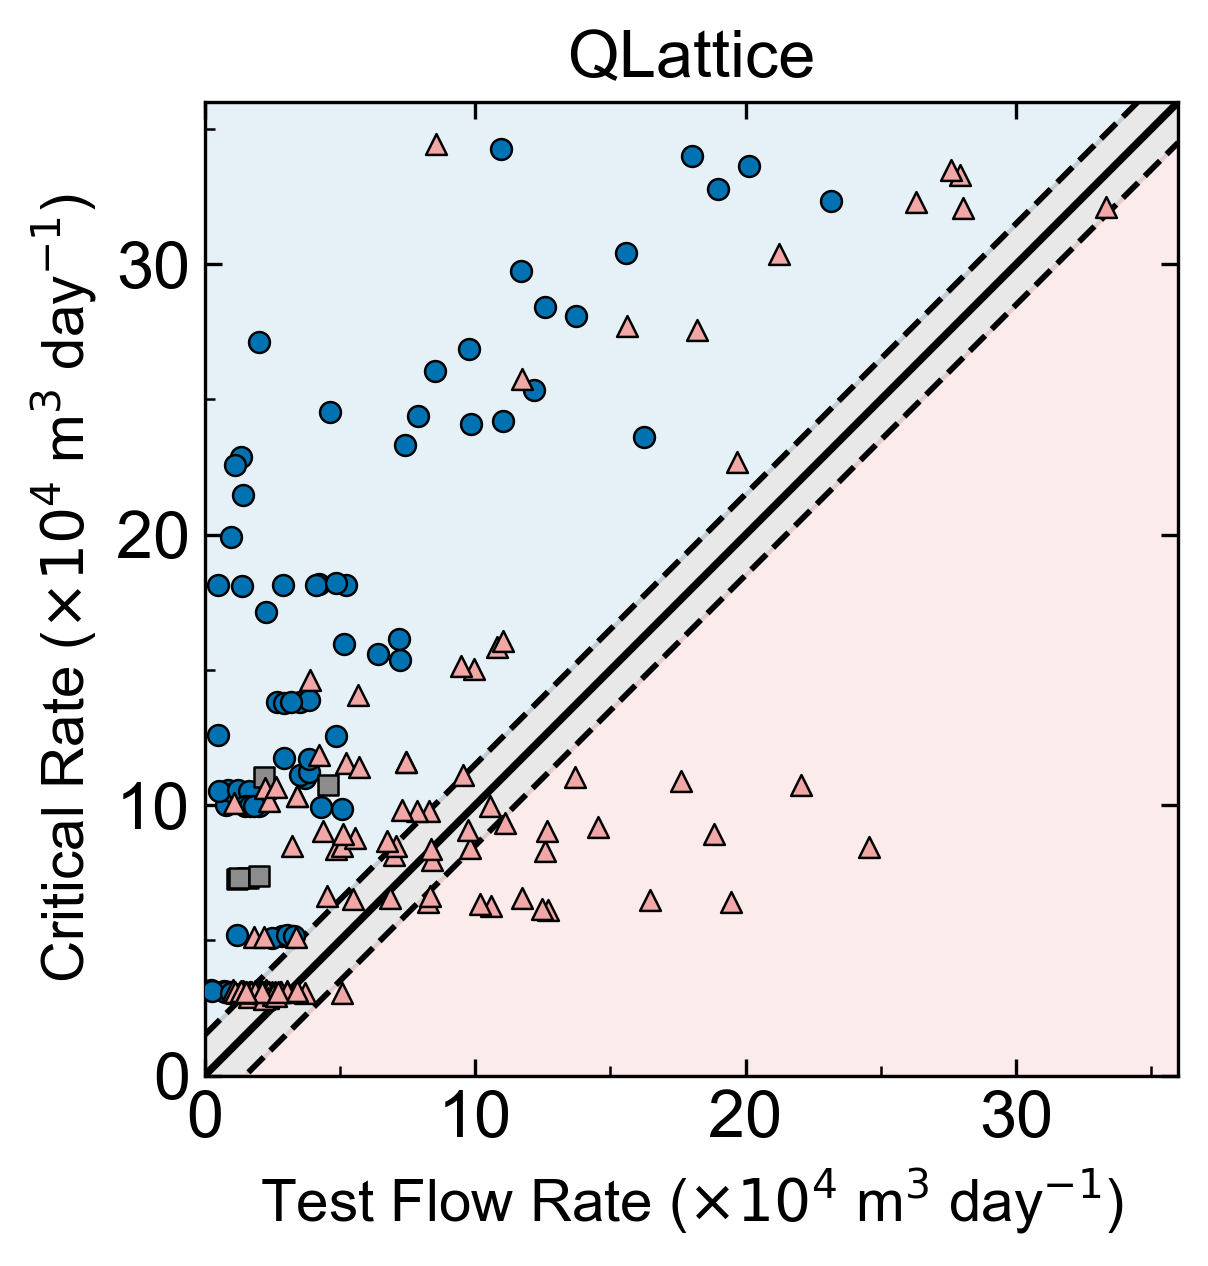

In [4]:
# -----------------------------
# Global journal-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 16,
    "axes.labelsize": 14,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "mathtext.fontset": "dejavusans",
})

# -----------------------------
# Domain
# -----------------------------
xmin, xmax = 0, 360000
x = np.linspace(xmin, xmax, 600)

# Parallel boundaries about y = x
delta = 15000
upper = x + delta
lower = x - delta

# -----------------------------
# Figure setup (journal aspect)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# -----------------------------
# Regions (print-safe, colorblind-safe)
# -----------------------------

# Unloaded
ax.fill_between(
    x,
    np.clip(upper, xmin, xmax),
    xmax,
    color="#0072B2",
    alpha=0.10,
    label="Loaded",
    zorder=1
)

# Near ILU
ax.fill_between(
    x,
    np.clip(lower, xmin, xmax),
    np.clip(upper, xmin, xmax),
    color="0.55",
    alpha=0.20,
    label="Near L.U",
    zorder=1
)

# Loaded
ax.fill_between(
    x,
    xmin,
    np.clip(lower, xmin, xmax),
    color="#F2A7A7",
    alpha=0.22,
    label="Unloaded",
    zorder=1
)

# -----------------------------
# Boundaries
# -----------------------------
ax.plot(x, x, color="black", linewidth=1.8, zorder=3)
ax.plot(x, upper, linestyle="--", color="black", linewidth=1.4, zorder=3)
ax.plot(x, lower, linestyle="--", color="black", linewidth=1.4, zorder=3)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Test Flow Rate (m$^3$ day$^{-1}$)")
ax.set_ylabel(r"Critical Rate (m$^3$ day$^{-1}$)")

ax.tick_params(length=4, width=0.8, top=True, right=True)
ax.tick_params(which="minor", length=2.5, width=0.6)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# -----------------------------
# Read CSV data
# -----------------------------
# CSV columns:
# Liquid droplet model, Test flow rate, Well status
df = pd.read_csv(r"./compariosn_mix.csv")

# -----------------------------
# Scatter styling by well status
# -----------------------------
status_style = {
    "Loaded":        {"marker": "o", "color": "#0072B2"},
    "Near L.U":   {"marker": "s", "color": "0.55"},
    "Unloaded":      {"marker": "^", "color": "#F2A7A7"},
    
}

# -----------------------------
# Plot data points
# -----------------------------
for status, style in status_style.items():
    subset = df[df["Well status"] == status]
    if subset.empty:
        continue

    ax.scatter(
        subset["Test flow rate"],
        subset["Qlattice model"],
        s=25,
        marker=style["marker"],
        facecolor=style["color"],
        edgecolor="black",
        linewidth=0.6,
        label=status,
        zorder=5
    )
    
    ax.set_title(
    "QLattice",
    fontsize=16,
    pad=6)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.set_xlabel(r"Test Flow Rate ($\times 10^4$ m$^3$ day$^{-1}$)")
    ax.set_ylabel(r"Critical Rate ($\times 10^4$ m$^3$ day$^{-1}$)")

# -----------------------------
# Legend (journal style)
# -----------------------------


plt.tight_layout()

# -----------------------------
# Save figures
# -----------------------------
plt.savefig("qlattice_new.pdf")
plt.savefig("qlattice_new.svg")
plt.savefig("qlattice_new.png")

plt.show()



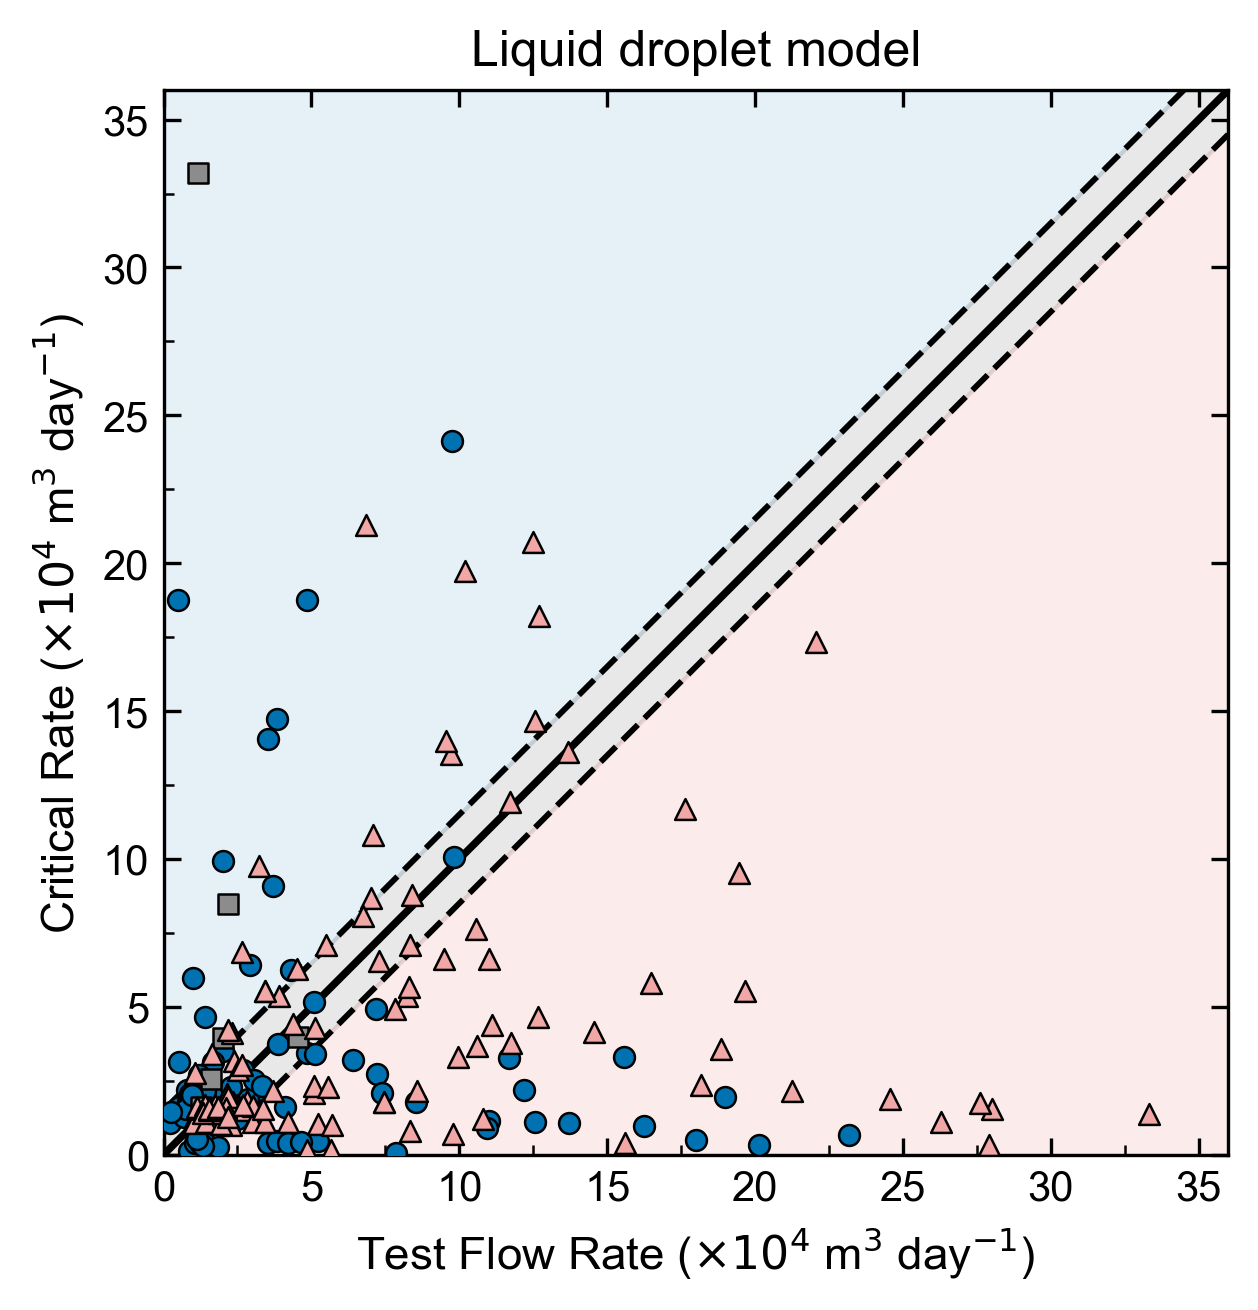

In [5]:
# -----------------------------
# Global journal-style settings
# -----------------------------
# -----------------------------
# Global journal-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "mathtext.fontset": "dejavusans",
})

# -----------------------------
# Domain
# -----------------------------
xmin, xmax = 0, 360000
x = np.linspace(xmin, xmax, 600)

# Parallel boundaries about y = x
delta = 15000
upper = x + delta
lower = x - delta

# -----------------------------
# Figure setup (journal aspect)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# -----------------------------
# Regions (print-safe, colorblind-safe)
# -----------------------------

# Unloaded
ax.fill_between(
    x,
    np.clip(upper, xmin, xmax),
    xmax,
    color="#0072B2",
    alpha=0.10,
    label="Loaded",
    zorder=1
)

# Near ILU
ax.fill_between(
    x,
    np.clip(lower, xmin, xmax),
    np.clip(upper, xmin, xmax),
    color="0.55",
    alpha=0.20,
    label="Near L.U",
    zorder=1
)

# Loaded
ax.fill_between(
    x,
    xmin,
    np.clip(lower, xmin, xmax),
    color="#F2A7A7",
    alpha=0.22,
    label="Unloaded",
    zorder=1
)

# -----------------------------
# Boundaries
# -----------------------------
ax.plot(x, x, color="black", linewidth=1.8, zorder=3)
ax.plot(x, upper, linestyle="--", color="black", linewidth=1.4, zorder=3)
ax.plot(x, lower, linestyle="--", color="black", linewidth=1.4, zorder=3)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Test Flow Rate (m$^3$ day$^{-1}$)")
ax.set_ylabel(r"Critical Rate (m$^3$ day$^{-1}$)")

ax.tick_params(length=4, width=0.8, top=True, right=True)
ax.tick_params(which="minor", length=2.5, width=0.6)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# -----------------------------
# Read CSV data
# -----------------------------
# CSV columns:
# Liquid droplet model, Test flow rate, Well status
df = pd.read_csv(r"./compariosn_mix.csv")

# -----------------------------
# Scatter styling by well status
# -----------------------------
status_style = {
    "Loaded":        {"marker": "o", "color": "#0072B2"},
    "Near L.U":   {"marker": "s", "color": "0.55"},
    "Unloaded":      {"marker": "^", "color": "#F2A7A7"},
    
}

# -----------------------------
# Plot data points
# -----------------------------
for status, style in status_style.items():
    subset = df[df["Well status"] == status]
    if subset.empty:
        continue

    ax.scatter(
        subset["Test flow rate"],
        subset["Liquid droplet model"],
        s=25,
        marker=style["marker"],
        facecolor=style["color"],
        edgecolor="black",
        linewidth=0.6,
        label=status,
        zorder=5
    )
    
    ax.set_title(
    "Liquid droplet model",
    fontsize=12,
    pad=6)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.set_xlabel(r"Test Flow Rate ($\times 10^4$ m$^3$ day$^{-1}$)")
    ax.set_ylabel(r"Critical Rate ($\times 10^4$ m$^3$ day$^{-1}$)")

# -----------------------------
# Legend (journal style)
# -----------------------------

plt.tight_layout()

# -----------------------------
# Save figures
# -----------------------------
plt.savefig("Liquid_droplet_model_new.pdf")
plt.savefig("Liquid_droplet_model_new.svg")
plt.savefig("Liquid_droplet_model_new.png")

plt.show()


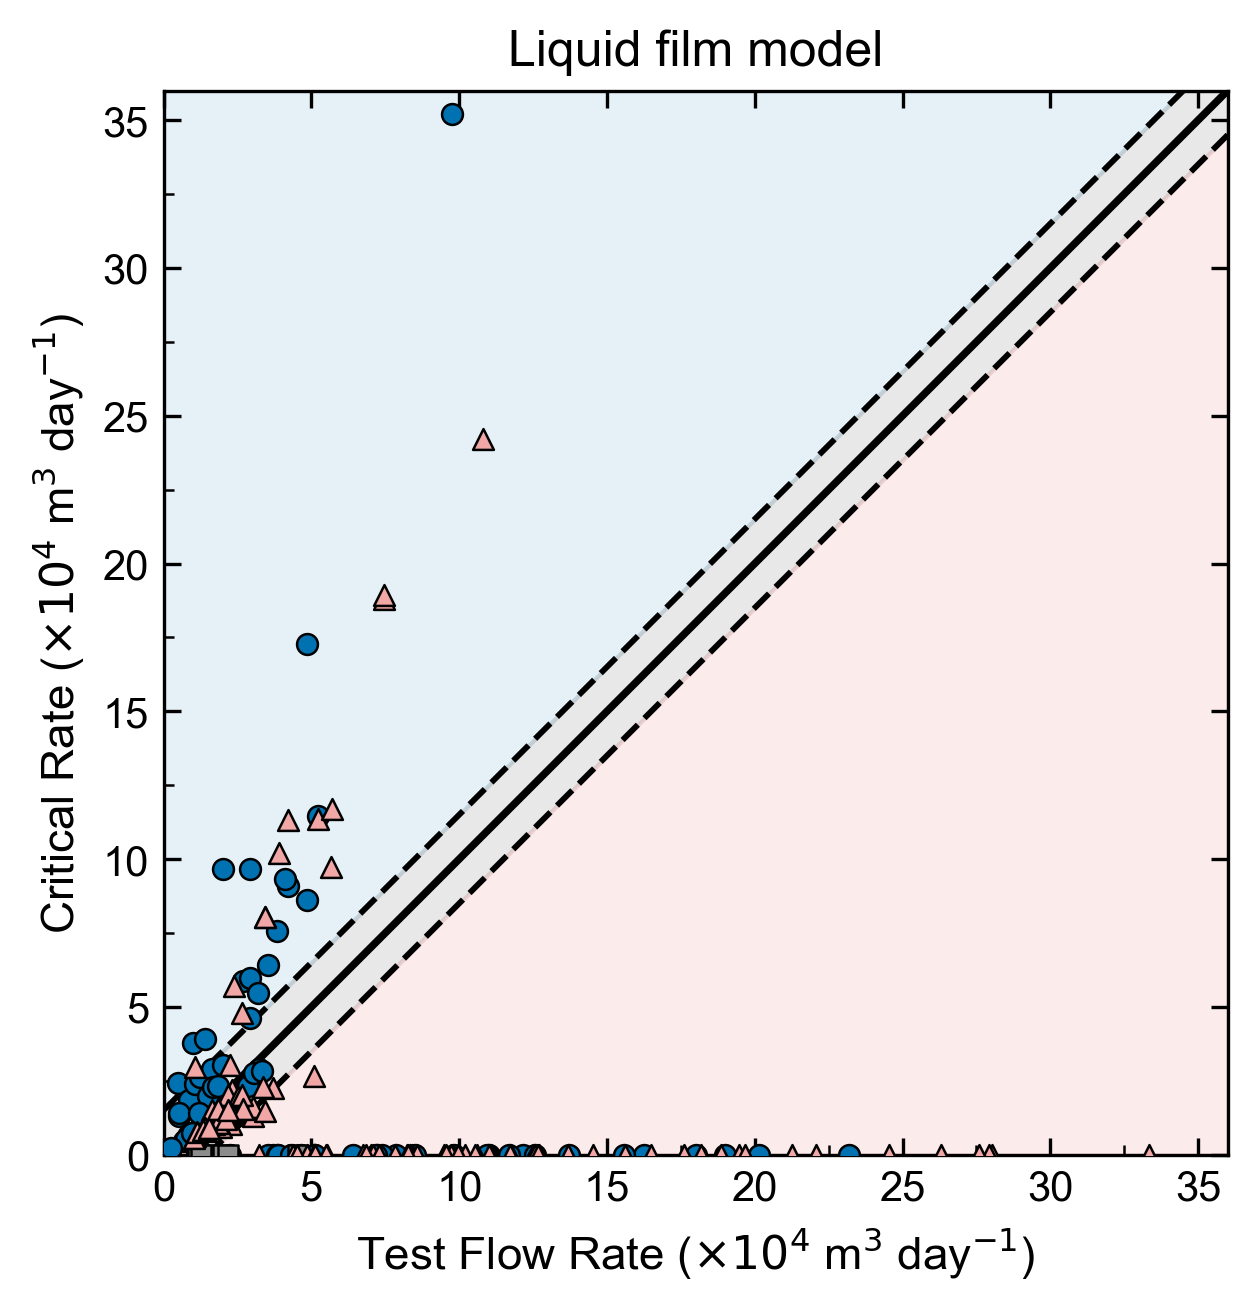

In [6]:
# -----------------------------
# Global journal-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "mathtext.fontset": "dejavusans",
})


# -----------------------------
# Domain
# -----------------------------
xmin, xmax = 0, 360000
x = np.linspace(xmin, xmax, 600)

# Parallel boundaries about y = x
delta = 15000
upper = x + delta
lower = x - delta

# -----------------------------
# Figure setup (journal aspect)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# -----------------------------
# Regions (print-safe, colorblind-safe)
# -----------------------------

# Unloaded
ax.fill_between(
    x,
    np.clip(upper, xmin, xmax),
    xmax,
    color="#0072B2",
    alpha=0.10,
    label="Loaded",
    zorder=1
)

# Near ILU
ax.fill_between(
    x,
    np.clip(lower, xmin, xmax),
    np.clip(upper, xmin, xmax),
    color="0.55",
    alpha=0.20,
    label="Near L.U",
    zorder=1
)

# Loaded
ax.fill_between(
    x,
    xmin,
    np.clip(lower, xmin, xmax),
    color="#F2A7A7",
    alpha=0.22,
    label="Unloaded",
    zorder=1
)

# -----------------------------
# Boundaries
# -----------------------------
ax.plot(x, x, color="black", linewidth=1.8, zorder=3)
ax.plot(x, upper, linestyle="--", color="black", linewidth=1.4, zorder=3)
ax.plot(x, lower, linestyle="--", color="black", linewidth=1.4, zorder=3)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Test Flow Rate (m$^3$ day$^{-1}$)")
ax.set_ylabel(r"Critical Rate (m$^3$ day$^{-1}$)")

ax.tick_params(length=4, width=0.8, top=True, right=True)
ax.tick_params(which="minor", length=2.5, width=0.6)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# -----------------------------
# Read CSV data
# -----------------------------
# CSV columns:
# Liquid droplet model, Test flow rate, Well status
df = pd.read_csv(r"./compariosn_mix.csv")

# -----------------------------
# Scatter styling by well status
# -----------------------------
status_style = {
    "Loaded":        {"marker": "o", "color": "#0072B2"},
    "Near L.U":   {"marker": "s", "color": "0.55"},
    "Unloaded":      {"marker": "^", "color": "#F2A7A7"},
    
}

# -----------------------------
# Plot data points
# -----------------------------
for status, style in status_style.items():
    subset = df[df["Well status"] == status]
    if subset.empty:
        continue

    ax.scatter(
        subset["Test flow rate"],
        subset["Liquid film model"],
        s=25,
        marker=style["marker"],
        facecolor=style["color"],
        edgecolor="black",
        linewidth=0.6,
        label=status,
        zorder=5
    )
    
    ax.set_title(
    "Liquid film model",
    fontsize=12,
    pad=6)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.set_xlabel(r"Test Flow Rate ($\times 10^4$ m$^3$ day$^{-1}$)")
    ax.set_ylabel(r"Critical Rate ($\times 10^4$ m$^3$ day$^{-1}$)")

# -----------------------------
# Legend (journal style)
# -----------------------------

plt.tight_layout()

# -----------------------------
# Save figures
# -----------------------------
plt.savefig("Liquid_film_model_new.pdf")
plt.savefig("Liquid_film_model_new.svg")
plt.savefig("Liquid_film_model_new.png")

plt.show()


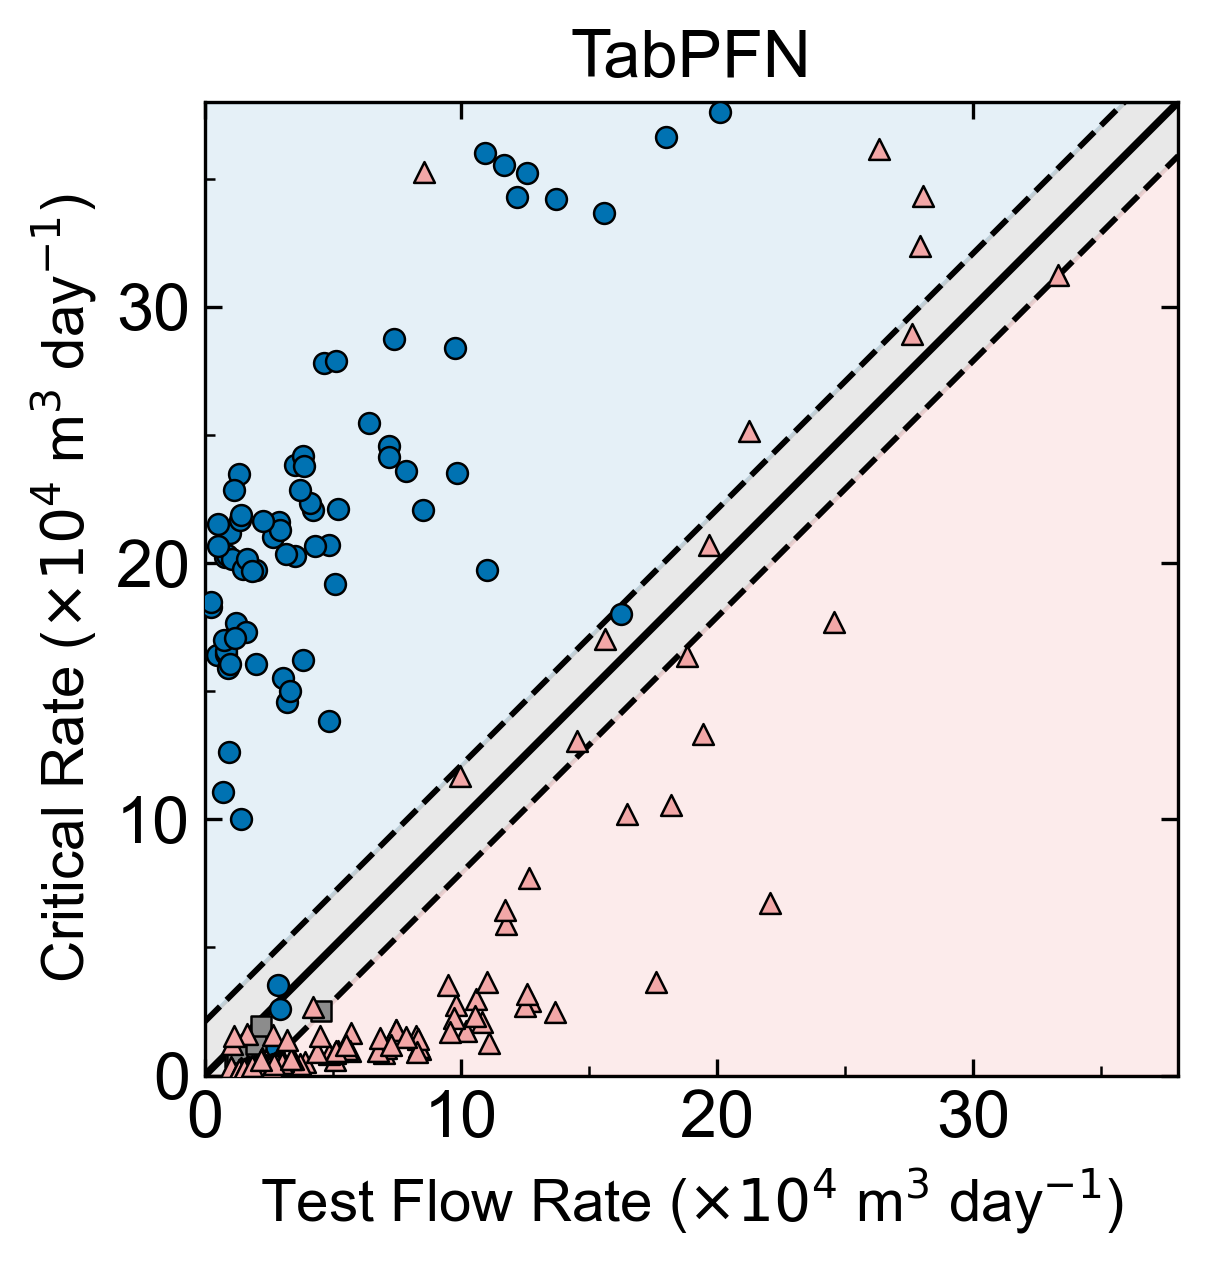

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import pandas as pd

# -----------------------------
# Global journal-style settings
# -----------------------------
# -----------------------------
# Global journal-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 16,
    "axes.labelsize": 14,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "mathtext.fontset": "dejavusans",
})


# -----------------------------
# Domain
# -----------------------------
xmin, xmax = 0, 380000
x = np.linspace(xmin, xmax, 600)

# Parallel boundaries about y = x
delta = 21000
upper = x + delta
lower = x - delta

# -----------------------------
# Figure setup (journal aspect)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# -----------------------------
# Regions (print-safe, colorblind-safe)
# -----------------------------

# Unloaded
ax.fill_between(
    x,
    np.clip(upper, xmin, xmax),
    xmax,
    color="#0072B2",
    alpha=0.10,
    label="Loaded",
    zorder=1
)

# Near ILU
ax.fill_between(
    x,
    np.clip(lower, xmin, xmax),
    np.clip(upper, xmin, xmax),
    color="0.55",
    alpha=0.20,
    label="Near L.U",
    zorder=1
)

# Loaded
ax.fill_between(
    x,
    xmin,
    np.clip(lower, xmin, xmax),
    color="#F2A7A7",
    alpha=0.22,
    label="Unloaded",
    zorder=1
)

# -----------------------------
# Boundaries
# -----------------------------
ax.plot(x, x, color="black", linewidth=1.8, zorder=3)
ax.plot(x, upper, linestyle="--", color="black", linewidth=1.4, zorder=3)
ax.plot(x, lower, linestyle="--", color="black", linewidth=1.4, zorder=3)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(r"Test Flow Rate (m$^3$ day$^{-1}$)")
ax.set_ylabel(r"Critical Rate (m$^3$ day$^{-1}$)")

ax.tick_params(length=4, width=0.8, top=True, right=True)
ax.tick_params(which="minor", length=2.5, width=0.6)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# -----------------------------
# Read CSV data
# -----------------------------
# CSV columns:
# Liquid droplet model, Test flow rate, Well status
df = pd.read_csv(r"./compariosn_mix.csv")

# -----------------------------
# Scatter styling by well status
# -----------------------------
status_style = {
    "Loaded":        {"marker": "o", "color": "#0072B2"},
    "Near L.U":   {"marker": "s", "color": "0.55"},
    "Unloaded":      {"marker": "^", "color": "#F2A7A7"},
    
}

# -----------------------------
# Plot data points
# -----------------------------
for status, style in status_style.items():
    subset = df[df["Well status"] == status]
    if subset.empty:
        continue

    ax.scatter(
        subset["Test flow rate"],
        subset["TabPFN model"],
        s=25,
        marker=style["marker"],
        facecolor=style["color"],
        edgecolor="black",
        linewidth=0.6,
        label=status,
        zorder=5
    )
    
    ax.set_title(
    "TabPFN",
    fontsize=16,
    pad=6)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val/1e4:.0f}"))
    ax.set_xlabel(r"Test Flow Rate ($\times 10^4$ m$^3$ day$^{-1}$)")
    ax.set_ylabel(r"Critical Rate ($\times 10^4$ m$^3$ day$^{-1}$)")

# -----------------------------
# Legend (journal style)
# -----------------------------


plt.tight_layout()

# -----------------------------
# Save figures
# -----------------------------
plt.savefig("tabPFN_new.pdf")
plt.savefig("tabPFN_new.svg")
plt.savefig("tabPFN_new.png")

plt.show()



Per-class accuracy (physics-consistent):
                    Unloaded  Near L.U    Loaded
Droplet-Film model  0.873874  0.833333  0.973333
Qlattice model      0.243243  0.000000  1.000000
TabPFN model        0.900901  0.833333  0.973333


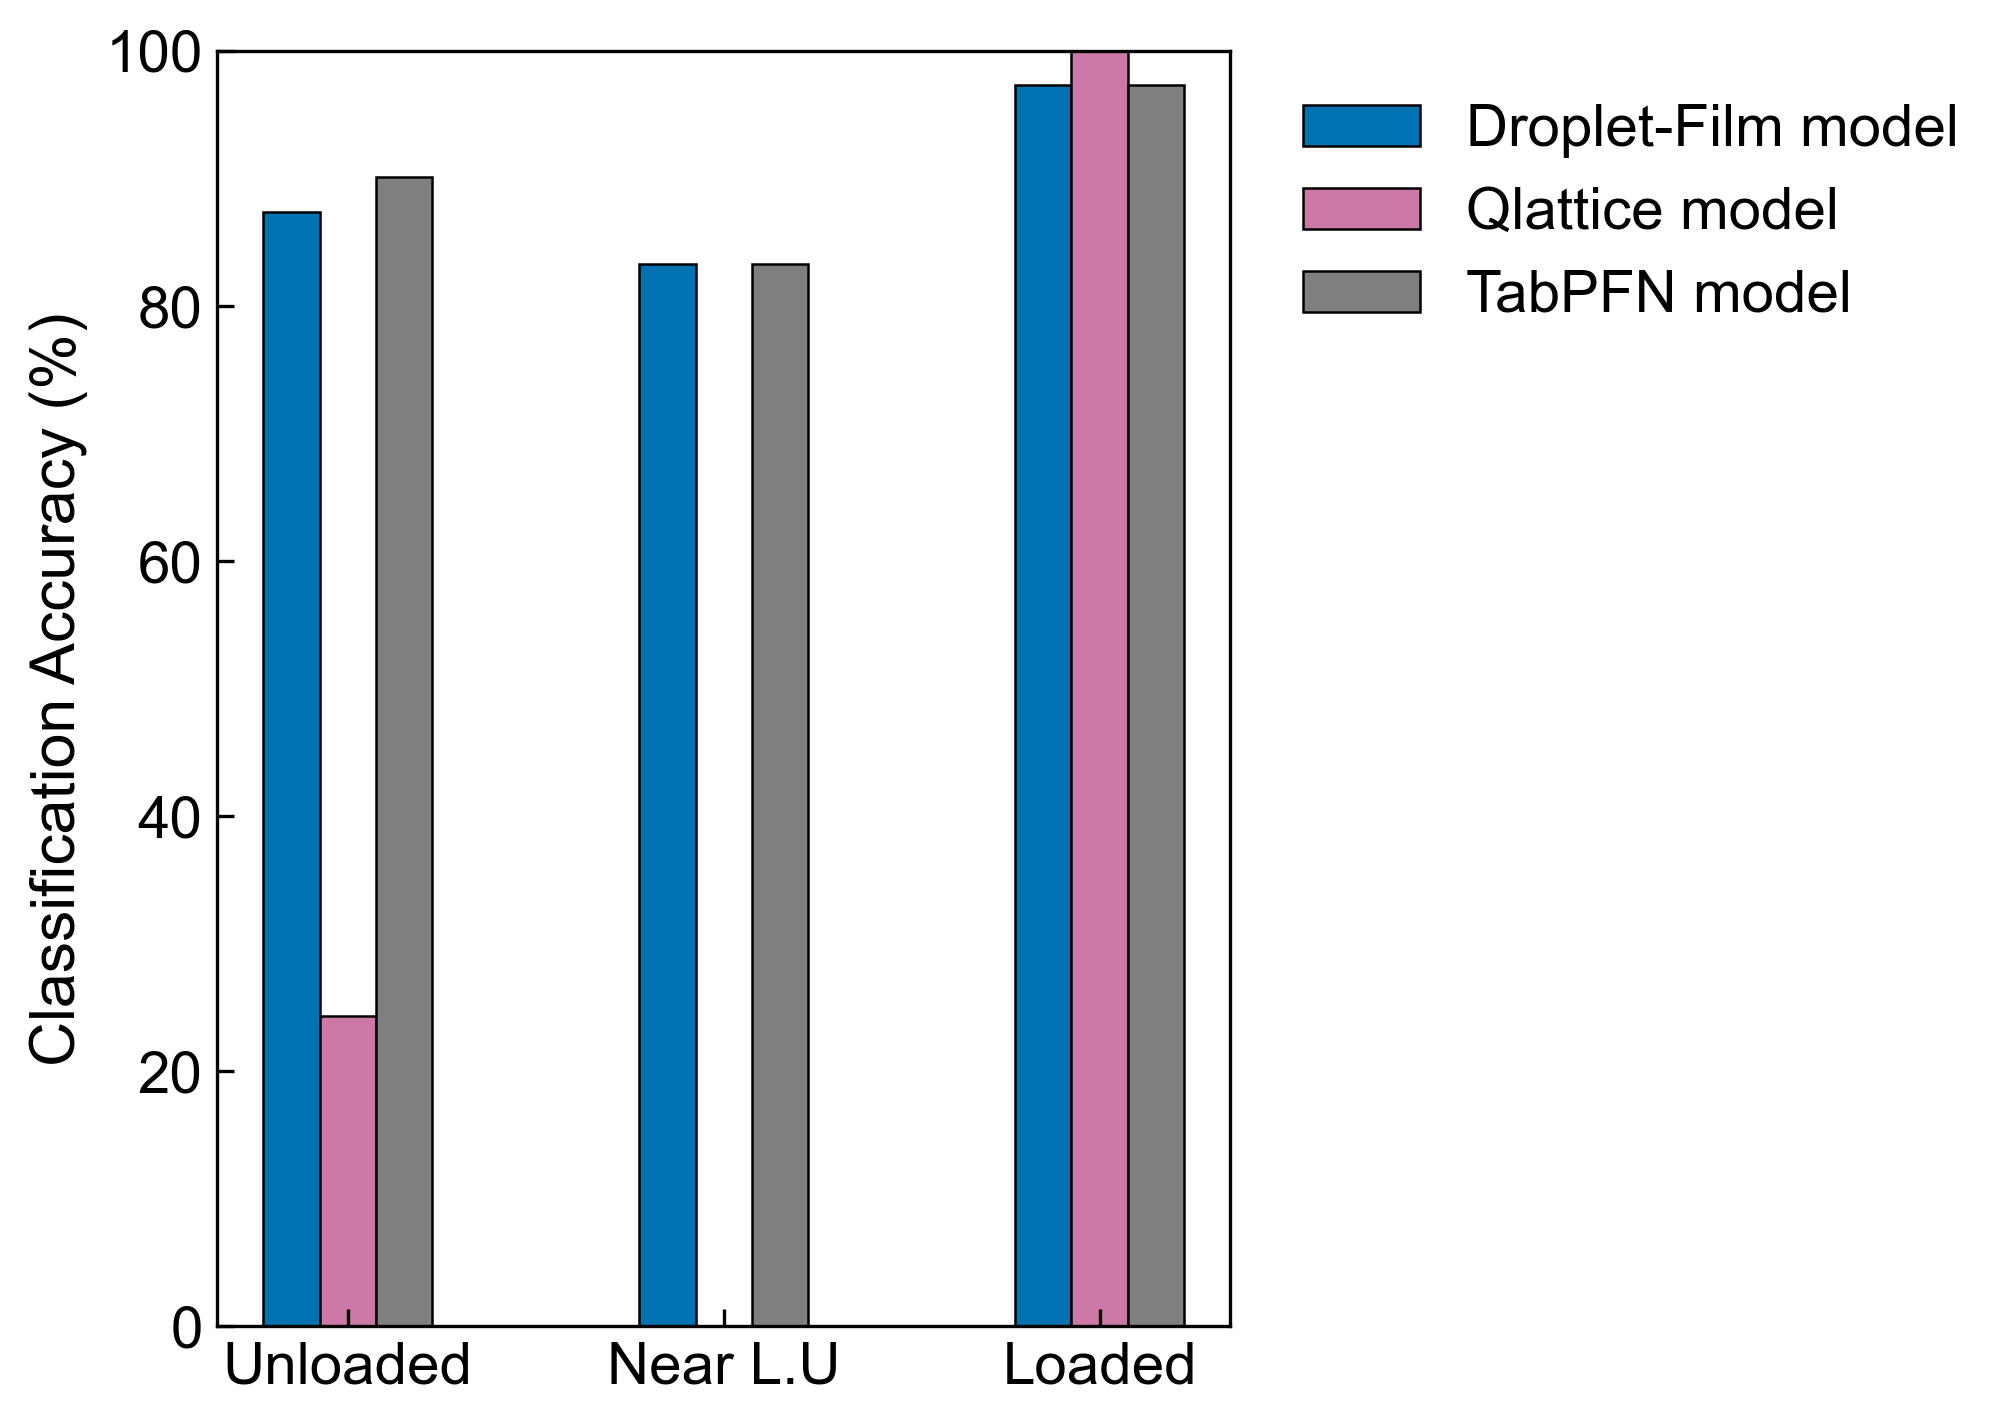

Empty DataFrame
Columns: [Test flow rate, Droplet-Film model, Qlattice model, TabPFN model, Droplet-Film model_abs_err, Qlattice model_abs_err, TabPFN model_abs_err]
Index: []


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Publication-quality matplotlib settings
# =====================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "mathtext.fontset": "dejavusans",
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})


# =====================================================
# Color-blind–safe palette (Okabe–Ito)
# =====================================================
PALETTE = {
    "Droplet-Film model": "#0072B2",
    "Qlattice model": "#CC79A7",
    "TabPFN model": "#7F7F7F",
}

# =====================================================
# Physics-consistent classification
# =====================================================
# =====================================================
# Physics-consistent classification (FIGURE-ALIGNED)
# =====================================================
def classify_with_near_lu(test_rate, critical_rate, delta=15000):
    """
    Classification exactly aligned with parity band used in the figure.

    Parameters
    ----------
    test_rate : float
        Measured test flow rate (m^3/day)
    critical_rate : float
        Model-predicted critical rate (m^3/day)
    delta : float
        Absolute tolerance defining Near L.U band (m^3/day)

    Returns
    -------
    physical_status : str
        Loaded or Unloaded based on parity
    near_lu : bool
        True if within ±delta parity band
    """
    physical_status = "Loaded" if critical_rate > test_rate else "Unloaded"
    near_lu = abs(critical_rate - test_rate) <= delta
    return physical_status, near_lu



# =====================================================
# Load and clean data
# =====================================================
csv_path = r"./compariosn_mix.csv"
df = pd.read_csv(csv_path)

valid_statuses = ["Unloaded", "Near L.U", "Loaded"]
df = df[df["Well status"].isin(valid_statuses)].copy()

models = list(PALETTE.keys())

# =====================================================
# Accuracy calculations (NEW LOGIC)
# =====================================================
# =====================================================
# Per-class accuracy (figure-consistent)
# =====================================================
per_class_accuracy = {}

for model in models:

    loaded_correct = loaded_total = 0
    unloaded_correct = unloaded_total = 0
    near_lu_correct = near_lu_total = 0

    for _, row in df.iterrows():

        true_status = row["Well status"]
        pred_status, pred_near = classify_with_near_lu(
            test_rate=row["Test flow rate"],
            critical_rate=row[model],
            delta=20194.55313  # EXACT match to figure
        )

        # ---------- Loaded ----------
        if true_status == "Loaded":
            loaded_total += 1
            if pred_status == "Loaded":
                loaded_correct += 1

        # ---------- Unloaded ----------
        if true_status == "Unloaded":
            unloaded_total += 1
            if pred_status == "Unloaded":
                unloaded_correct += 1

        # ---------- Near L.U (proximity accuracy) ----------
        if true_status == "Near L.U":
            near_lu_total += 1
            if pred_near:
                near_lu_correct += 1

    per_class_accuracy[model] = {
        "Unloaded": unloaded_correct / unloaded_total if unloaded_total else np.nan,
        "Near L.U": near_lu_correct / near_lu_total if near_lu_total else np.nan,
        "Loaded": loaded_correct / loaded_total if loaded_total else np.nan,
    }

per_class_df = pd.DataFrame(per_class_accuracy).T


print("\nPer-class accuracy (physics-consistent):")
print(per_class_df)

# =====================================================
# Plot: Per-class accuracy (publication-ready)
# =====================================================
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(valid_statuses))
width = 0.15

for i, model in enumerate(models):
    ax.bar(
        x + i * width,
        [per_class_df.loc[model, s] for s in valid_statuses],
        width,
        label=model,
        color=PALETTE[model],
        edgecolor="black",
        linewidth=0.6
    )

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(valid_statuses)

ax.set_ylabel("Classification Accuracy (%)")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val*100:.0f}"))
ax.set_ylim(0, 1)


ax.legend(
    frameon=False,
    fontsize=14,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)


for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("per_class_accuracy_colorblind.png")
plt.savefig("per_class_accuracy_colorblind.pdf")
plt.savefig("per_class_accuracy_colorblind.svg")
plt.show()

mask = df["Well status"] == "Near Loaded"

df_diag = df.loc[mask, [
    "Test flow rate",
    "Droplet-Film model",
    "Qlattice model",
    "TabPFN model"
]].copy()

for model in ["Droplet-Film model", "Qlattice model", "TabPFN model"]:
    df_diag[f"{model}_abs_err"] = abs(
        df_diag[model] - df_diag["Test flow rate"]
    )

print(df_diag.sort_values("TabPFN model_abs_err", ascending=False))



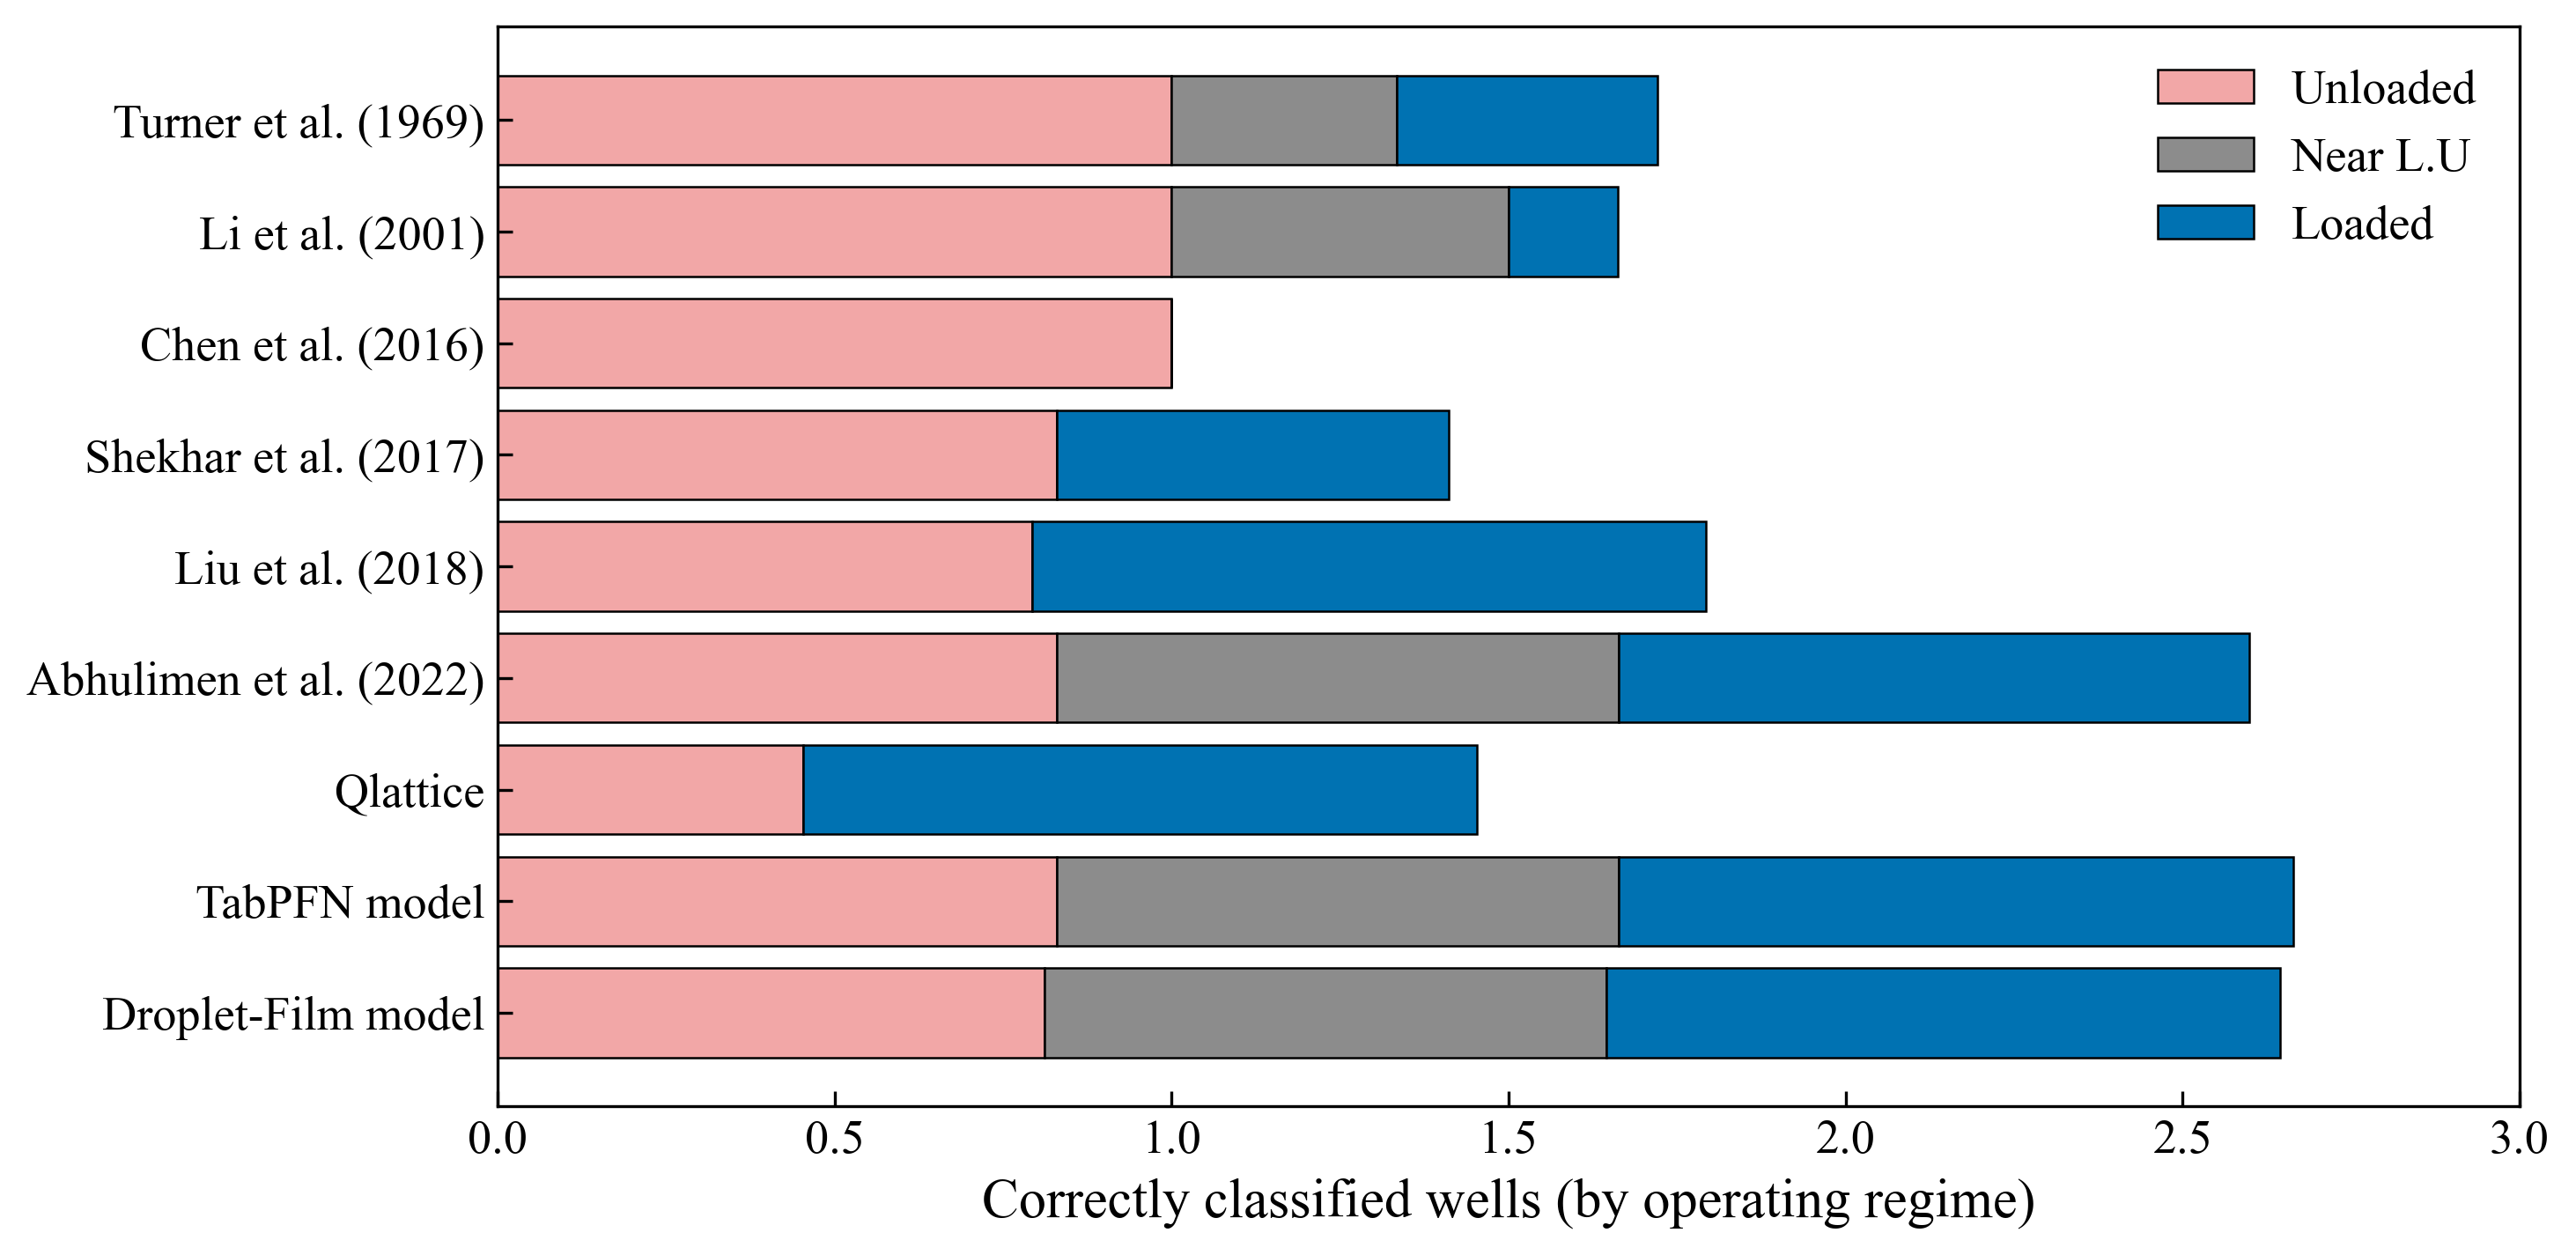

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Publication-quality matplotlib settings
# =====================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

# =====================================================
# Raw data from literature + models
# =====================================================
data = {
    "Model": [
        "Turner et al. (1969)",
        "Li et al. (2001)",
        "Chen et al. (2016)",
        "Shekhar et al. (2017)",
        "Liu et al. (2018)",
        "Abhulimen et al. (2022)",
        "Qlattice",
        "TabPFN model",
        "Droplet-Film model",
    ],
    "Unloaded": [
        53/53, 53/53, 53/53, 44/53, 42/53, 44/53, 24/53, 44/53, 43/53
    ],
    "Near L.U": [
        2/6, 3/6, 0/6, 0/6, 0/6, 5/6, 0/6, 5/6, 5/6
    ],
    "Loaded": [
        12/31, 5/31, 0/31, 18/31, 31/31, 29/31, 31/31, 31/31, 31/31
    ]
}

df = pd.DataFrame(data)

# =====================================================
# YOUR requested color scheme
# =====================================================
COLORS = {
    "Loaded": "#0072B2",     # blue
    "Near L.U": "0.55",      # gray
    "Unloaded": "#F2A7A7",   # soft red
}

# =====================================================
# Plot: Stacked per-class performance
# =====================================================
fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(df))
left = np.zeros(len(df))

# Order matters for visual logic (Unloaded → Near → Loaded)
for cls in ["Unloaded", "Near L.U", "Loaded"]:
    ax.barh(
        y,
        df[cls],
        left=left,
        color=COLORS[cls],
        edgecolor="black",
        linewidth=0.6,
        label=cls
    )
    left += df[cls]

# -----------------------------------------------------
# Axes formatting
# -----------------------------------------------------
ax.set_yticks(y)
ax.set_yticklabels(df["Model"])
ax.set_xlim(0, 3)
ax.set_xlabel("Correctly classified wells (by operating regime)")
# ax.set_title("Per-class performance comparison with published models")

ax.invert_yaxis()

# -----------------------------------------------------
# Legend
# -----------------------------------------------------
ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=13
)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("stacked_class_performance_colorscheme.png")
plt.savefig("stacked_class_performance_colorscheme.pdf")
plt.show()


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Publication-quality matplotlib settings
# =====================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

# =====================================================
# Color-blind–safe palette (Okabe–Ito)
# =====================================================
PALETTE = {
    "Droplet-Film model": "#0072B2",
    "XGBoost model": "#CC79A7",
    "TabPFN model": "#7F7F7F",
}

# =====================================================
# Physics-consistent classification
# =====================================================
def classify_with_near_lu(test_rate, critical_rate, delta=15000):
    """
    Returns:
      physical_status: Loaded / Unloaded
      near_lu: True if within ±delta of parity
    """
    if critical_rate >= test_rate:
        physical_status = "Loaded"
    else:
        physical_status = "Unloaded"

    near_lu = abs(critical_rate - test_rate) <= delta
    return physical_status, near_lu

# =====================================================
# Load and clean data
# =====================================================
csv_path = r"C:\Users\awwalola\Desktop\Research\compariosn_mix2.csv"
df = pd.read_csv(csv_path)

valid_statuses = ["Unloaded", "Near L.U", "Loaded"]
df = df[df["Well status"].isin(valid_statuses)].copy()

models = list(PALETTE.keys())

# =====================================================
# Accuracy calculations (NEW LOGIC)
# =====================================================
per_class_accuracy = {}

for model in models:

    loaded_correct = loaded_total = 0
    unloaded_correct = unloaded_total = 0
    near_lu_correct = near_lu_total = 0

    for _, row in df.iterrows():

        true_status = row["Well status"]
        pred_status, pred_near = classify_with_near_lu(
            test_rate=row["Test flow rate"],
            critical_rate=row[model]
        )

        # ---------- Loaded ----------
        if true_status == "Loaded":
            loaded_total += 1
            if pred_status == "Loaded":
                loaded_correct += 1

        # ---------- Unloaded ----------
        if true_status == "Unloaded":
            unloaded_total += 1
            if pred_status == "Unloaded":
                unloaded_correct += 1

        # ---------- Near L.U (proximity accuracy) ----------
        if true_status == "Near L.U":
            near_lu_total += 1
            if pred_near:
                near_lu_correct += 1

    print (unloaded_correct)
#     print (unloaded_correct)   
    per_class_accuracy[model] = {
        "Unloaded": unloaded_correct / unloaded_total if unloaded_total else np.nan,
        "Near L.U": near_lu_correct / near_lu_total if near_lu_total else np.nan,
        "Loaded": loaded_correct / loaded_total if loaded_total else np.nan,
    }

per_class_df = pd.DataFrame(per_class_accuracy).T

print("\nPer-class accuracy (physics-consistent):")
print(per_class_df)

# =====================================================
# Plot: Per-class accuracy (publication-ready)
# =====================================================
fig, ax = plt.subplots(figsize=(6, 2))

x = np.arange(len(valid_statuses))
width = 0.15

for i, model in enumerate(models):
    ax.bar(
        x + i * width,
        [per_class_df.loc[model, s] for s in valid_statuses],
        width,
        label=model,
        color=PALETTE[model],
        edgecolor="black",
        linewidth=0.6
    )

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(valid_statuses)

ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Per-class classification accuracy")

ax.legend(
    frameon=False,
    fontsize=14,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("per_class_accuracy_colorblind.png")
plt.savefig("per_class_accuracy_colorblind.pdf")
plt.show()

mask = df["Well status"] == "Near L.U"

df_diag = df.loc[mask, [
    "Test flow rate",
    "Droplet-Film model",
    "Qlattice model",
    "TabPFN model"
]].copy()

for model in ["Droplet-Film model", "Qlattice model", "TabPFN model"]:
    df_diag[f"{model}_abs_err"] = abs(
        df_diag[model] - df_diag["Test flow rate"]
    )

print(df_diag.sort_values("TabPFN model_abs_err", ascending=False))


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\awwalola\\Desktop\\Research\\compariosn_mix2.csv'

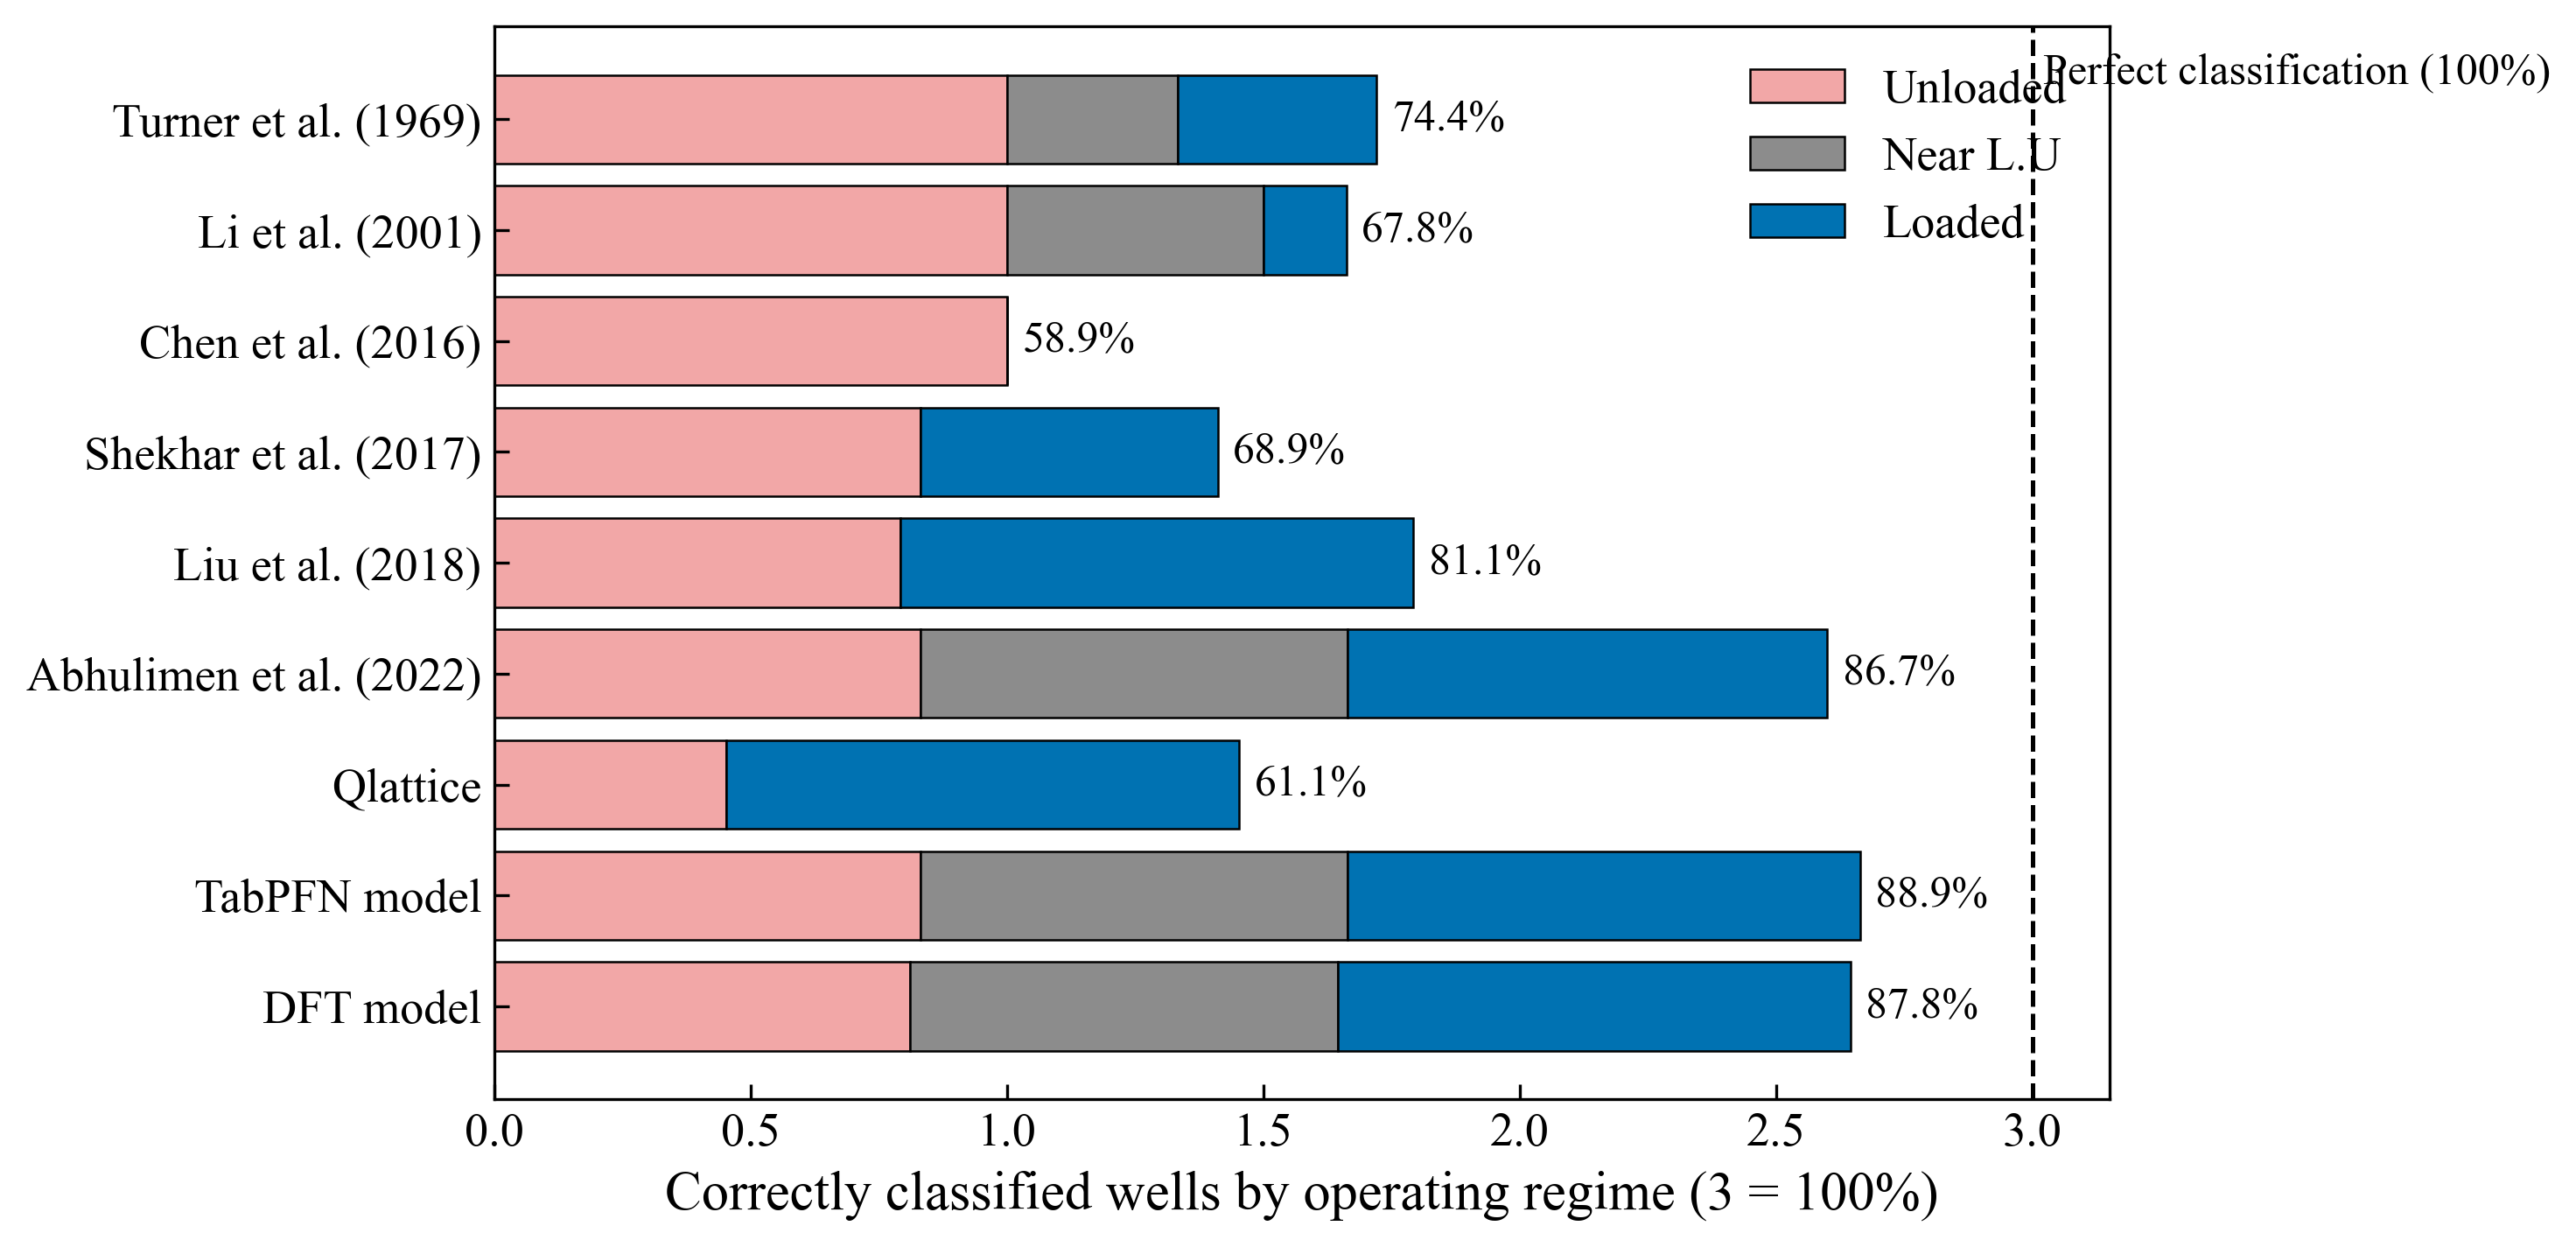

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Publication-quality matplotlib settings
# =====================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

# =====================================================
# Raw data
# =====================================================
data = {
    "Model": [
        "Turner et al. (1969)",
        "Li et al. (2001)",
        "Chen et al. (2016)",
        "Shekhar et al. (2017)",
        "Liu et al. (2018)",
        "Abhulimen et al. (2022)",
        "Qlattice",
        "TabPFN model",
        "Droplet-Film model",
    ],
    "Unloaded": [
        53/53, 53/53, 53/53, 44/53, 42/53, 44/53, 24/53, 44/53, 43/53
    ],
    "Near L.U": [
        2/6, 3/6, 0/6, 0/6, 0/6, 5/6, 0/6, 5/6, 5/6
    ],
    "Loaded": [
        12/31, 5/31, 0/31, 18/31, 31/31, 29/31, 31/31, 31/31, 31/31
    ]
}

df = pd.DataFrame(data)

# =====================================================
# Class counts (CRITICAL for correct accuracy)
# =====================================================
N_UNLOADED = 53
N_NEAR = 6
N_LOADED = 31
N_TOTAL = N_UNLOADED + N_NEAR + N_LOADED  # 90

# =====================================================
# Color scheme
# =====================================================
COLORS = {
    "Loaded": "#0072B2",
    "Near L.U": "0.55",
    "Unloaded": "#F2A7A7",
}

# =====================================================
# Plot
# =====================================================
fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(df))
left = np.zeros(len(df))

for cls in ["Unloaded", "Near L.U", "Loaded"]:
    ax.barh(
        y,
        df[cls],
        left=left,
        color=COLORS[cls],
        edgecolor="black",
        linewidth=0.6,
        label=cls
    )
    left += df[cls]

# =====================================================
# Perfect classification reference
# =====================================================
ax.axvline(3.0, color="black", linestyle="--", linewidth=1.2)
ax.text(
    3.02,
    -0.6,
    "Perfect classification (100%)",
    va="top",
    ha="left",
    fontsize=12
)

# =====================================================
# CORRECT total accuracy (% of all wells)
# =====================================================
correct_predictions = (
    df["Unloaded"] * N_UNLOADED +
    df["Near L.U"] * N_NEAR +
    df["Loaded"] * N_LOADED
)

total_accuracy = correct_predictions / N_TOTAL * 100

for i, acc in enumerate(total_accuracy):
    ax.text(
        left[i] + 0.03,
        i,
        f"{acc:.1f}%",
        va="center",
        ha="left",
        fontsize=12
    )

# =====================================================
# Axes & legend
# =====================================================
ax.set_yticks(y)
ax.set_yticklabels(df["Model"])
ax.set_xlim(0, 3.15)
ax.set_xlabel(
    "Correctly classified wells by operating regime (3 = 100%)"
)

ax.invert_yaxis()

ax.legend(frameon=False, loc="upper right", fontsize=13)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("stacked_class_performance_reviewer_proof.png")
plt.savefig("stacked_class_performance_reviewer_proof.pdf")
plt.show()


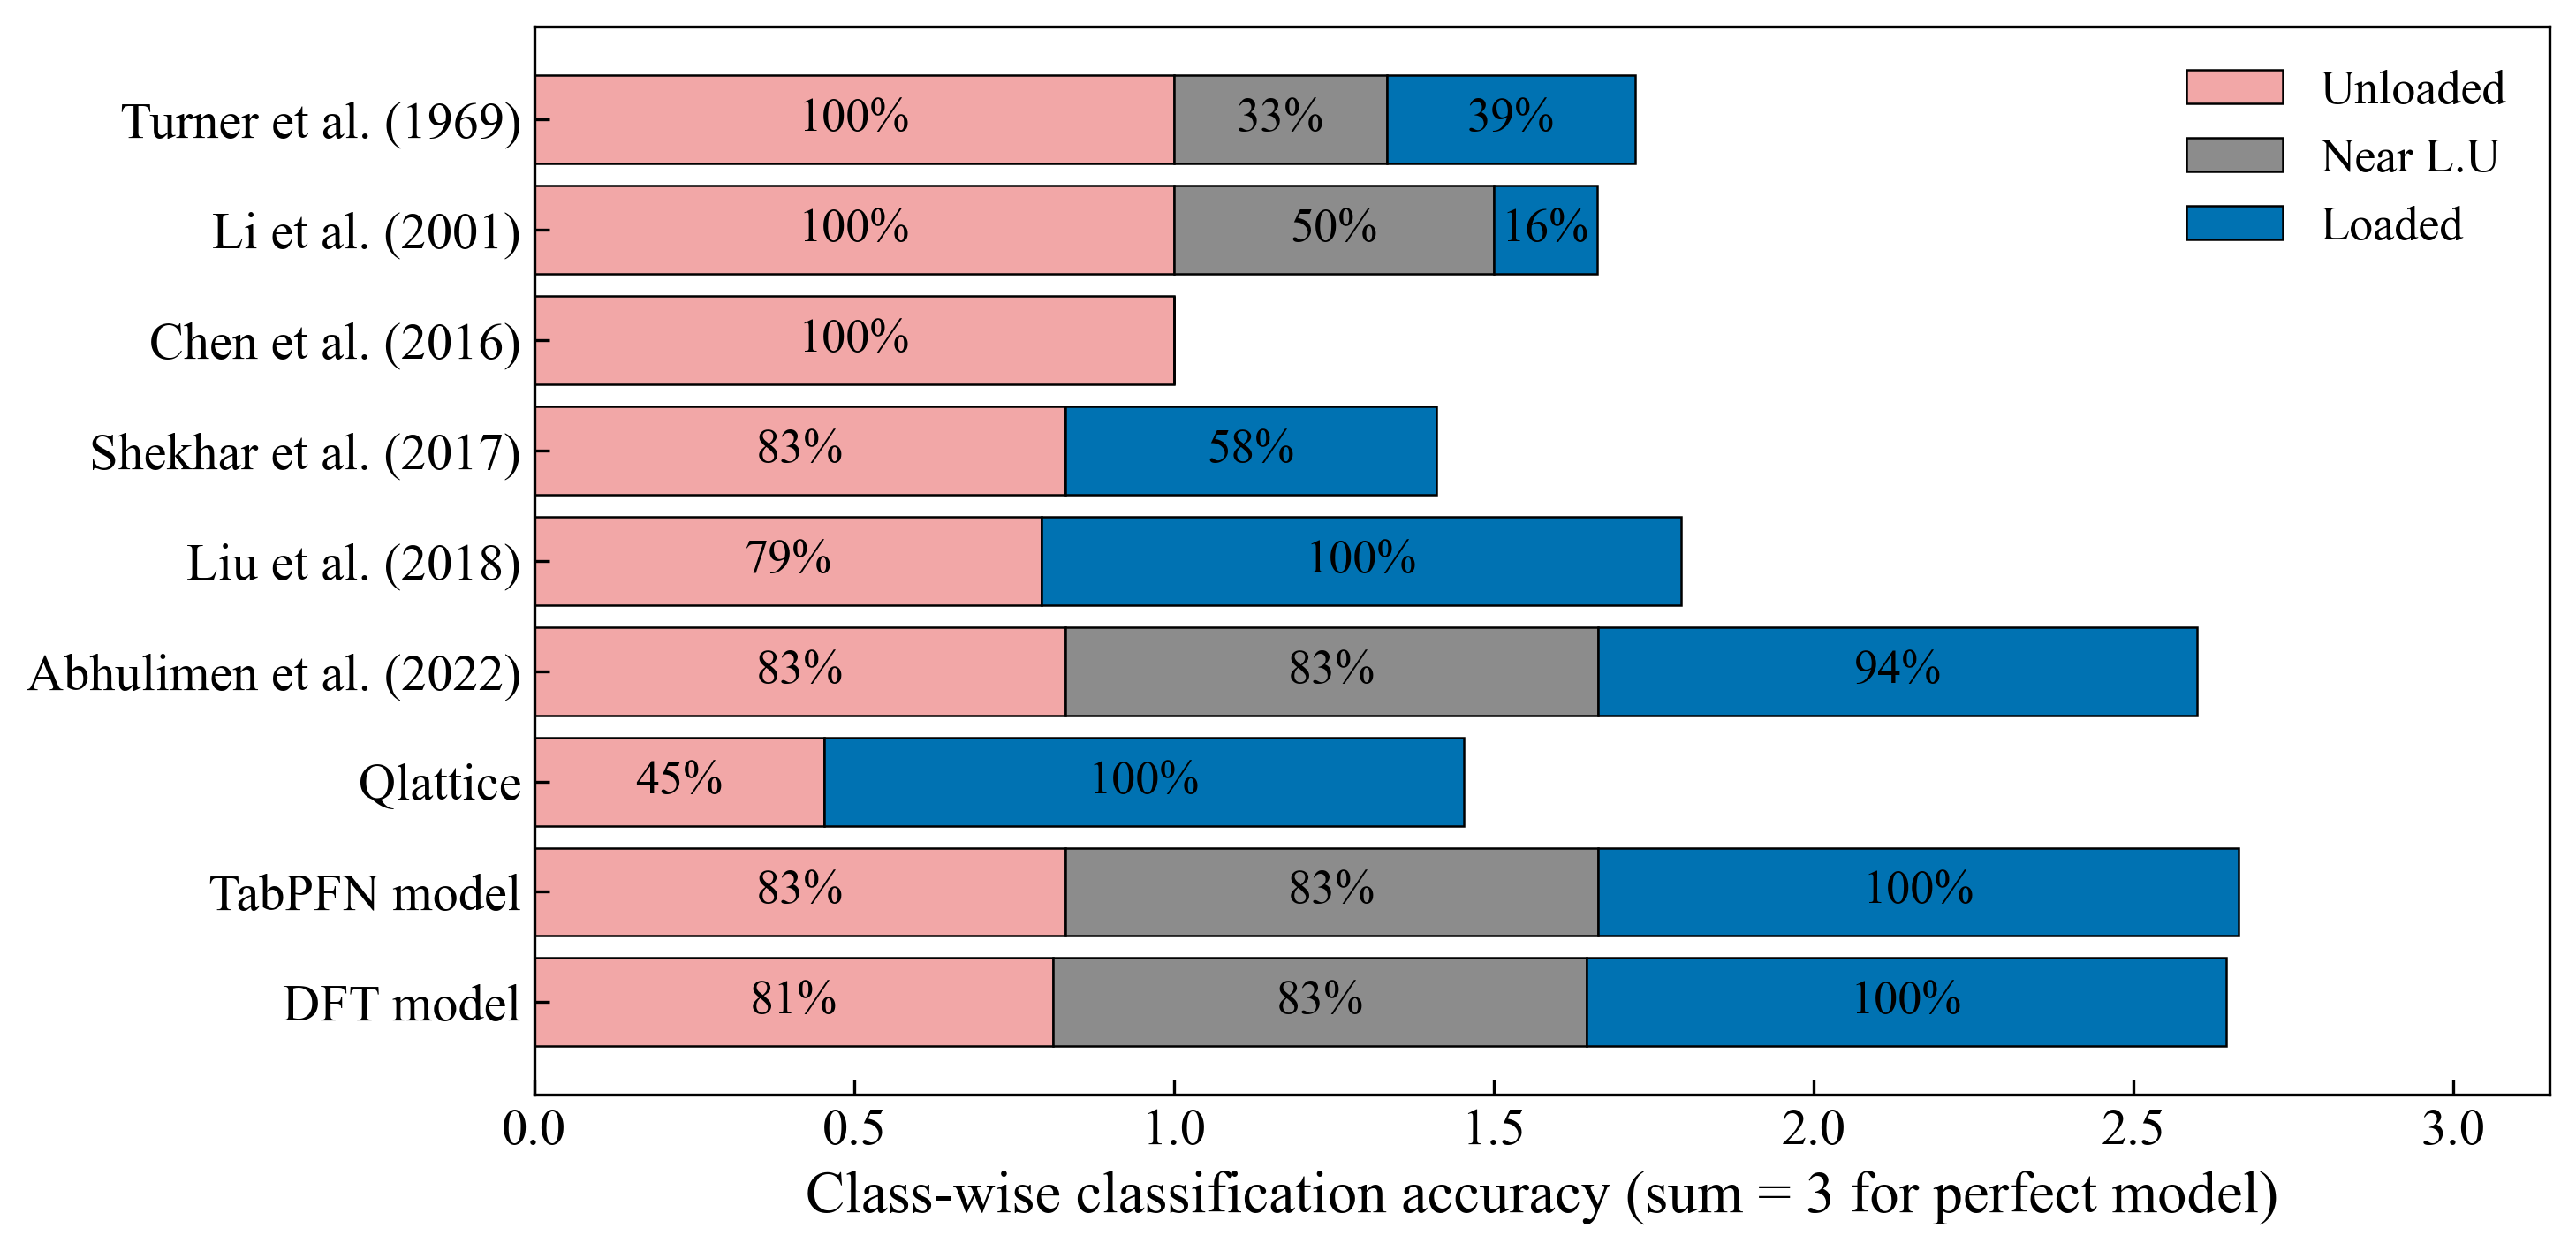

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Publication-quality matplotlib settings
# =====================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

# =====================================================
# Raw data
# =====================================================
data = {
    "Model": [
        "Turner et al. (1969)",
        "Li et al. (2001)",
        "Chen et al. (2016)",
        "Shekhar et al. (2017)",
        "Liu et al. (2018)",
        "Abhulimen et al. (2022)",
        "Qlattice",
        "TabPFN model",
        "Droplet-Film model",
    ],
    "Unloaded": [
        53/53, 53/53, 53/53, 44/53, 42/53, 44/53, 24/53, 44/53, 43/53
    ],
    "Near L.U": [
        2/6, 3/6, 0/6, 0/6, 0/6, 5/6, 0/6, 5/6, 5/6
    ],
    "Loaded": [
        12/31, 5/31, 0/31, 18/31, 31/31, 29/31, 31/31, 31/31, 31/31
    ]
}

df = pd.DataFrame(data)

# =====================================================
# Color scheme
# =====================================================
COLORS = {
    "Loaded": "#0072B2",
    "Near L.U": "0.55",
    "Unloaded": "#F2A7A7",
}

# =====================================================
# Plot
# =====================================================
fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(df))
left = np.zeros(len(df))

# -----------------------------------------------------
# Stacked bars + class-wise annotations
# -----------------------------------------------------
for cls in ["Unloaded", "Near L.U", "Loaded"]:
    values = df[cls].values

    ax.barh(
        y,
        values,
        left=left,
        color=COLORS[cls],
        edgecolor="black",
        linewidth=0.6,
        label=cls
    )

    # Class-wise accuracy annotation
    for i, v in enumerate(values):
        if v > 0.05:  # avoid clutter for tiny segments
            ax.text(
                left[i] + v / 2,
                i,
                f"{v*100:.0f}%",
                va="center",
                ha="center",
                fontsize=13,
                color="black"
            )

    left += values

# =====================================================
# Perfect classification reference
# =====================================================
# ax.axvline(3.0, color="black", linestyle="--", linewidth=1.2)


# =====================================================
# Axes & legend
# =====================================================
ax.set_yticks(y)
ax.set_yticklabels(df["Model"])
ax.set_xlim(0, 3.15)
ax.set_xlabel(
    "Class-wise classification accuracy (sum = 3 for perfect model)"
)

ax.invert_yaxis()

ax.legend(frameon=False, loc="upper right", fontsize=13)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("stacked_classwise_accuracy.png")
plt.savefig("stacked_classwise_accuracy.pdf")
plt.show()


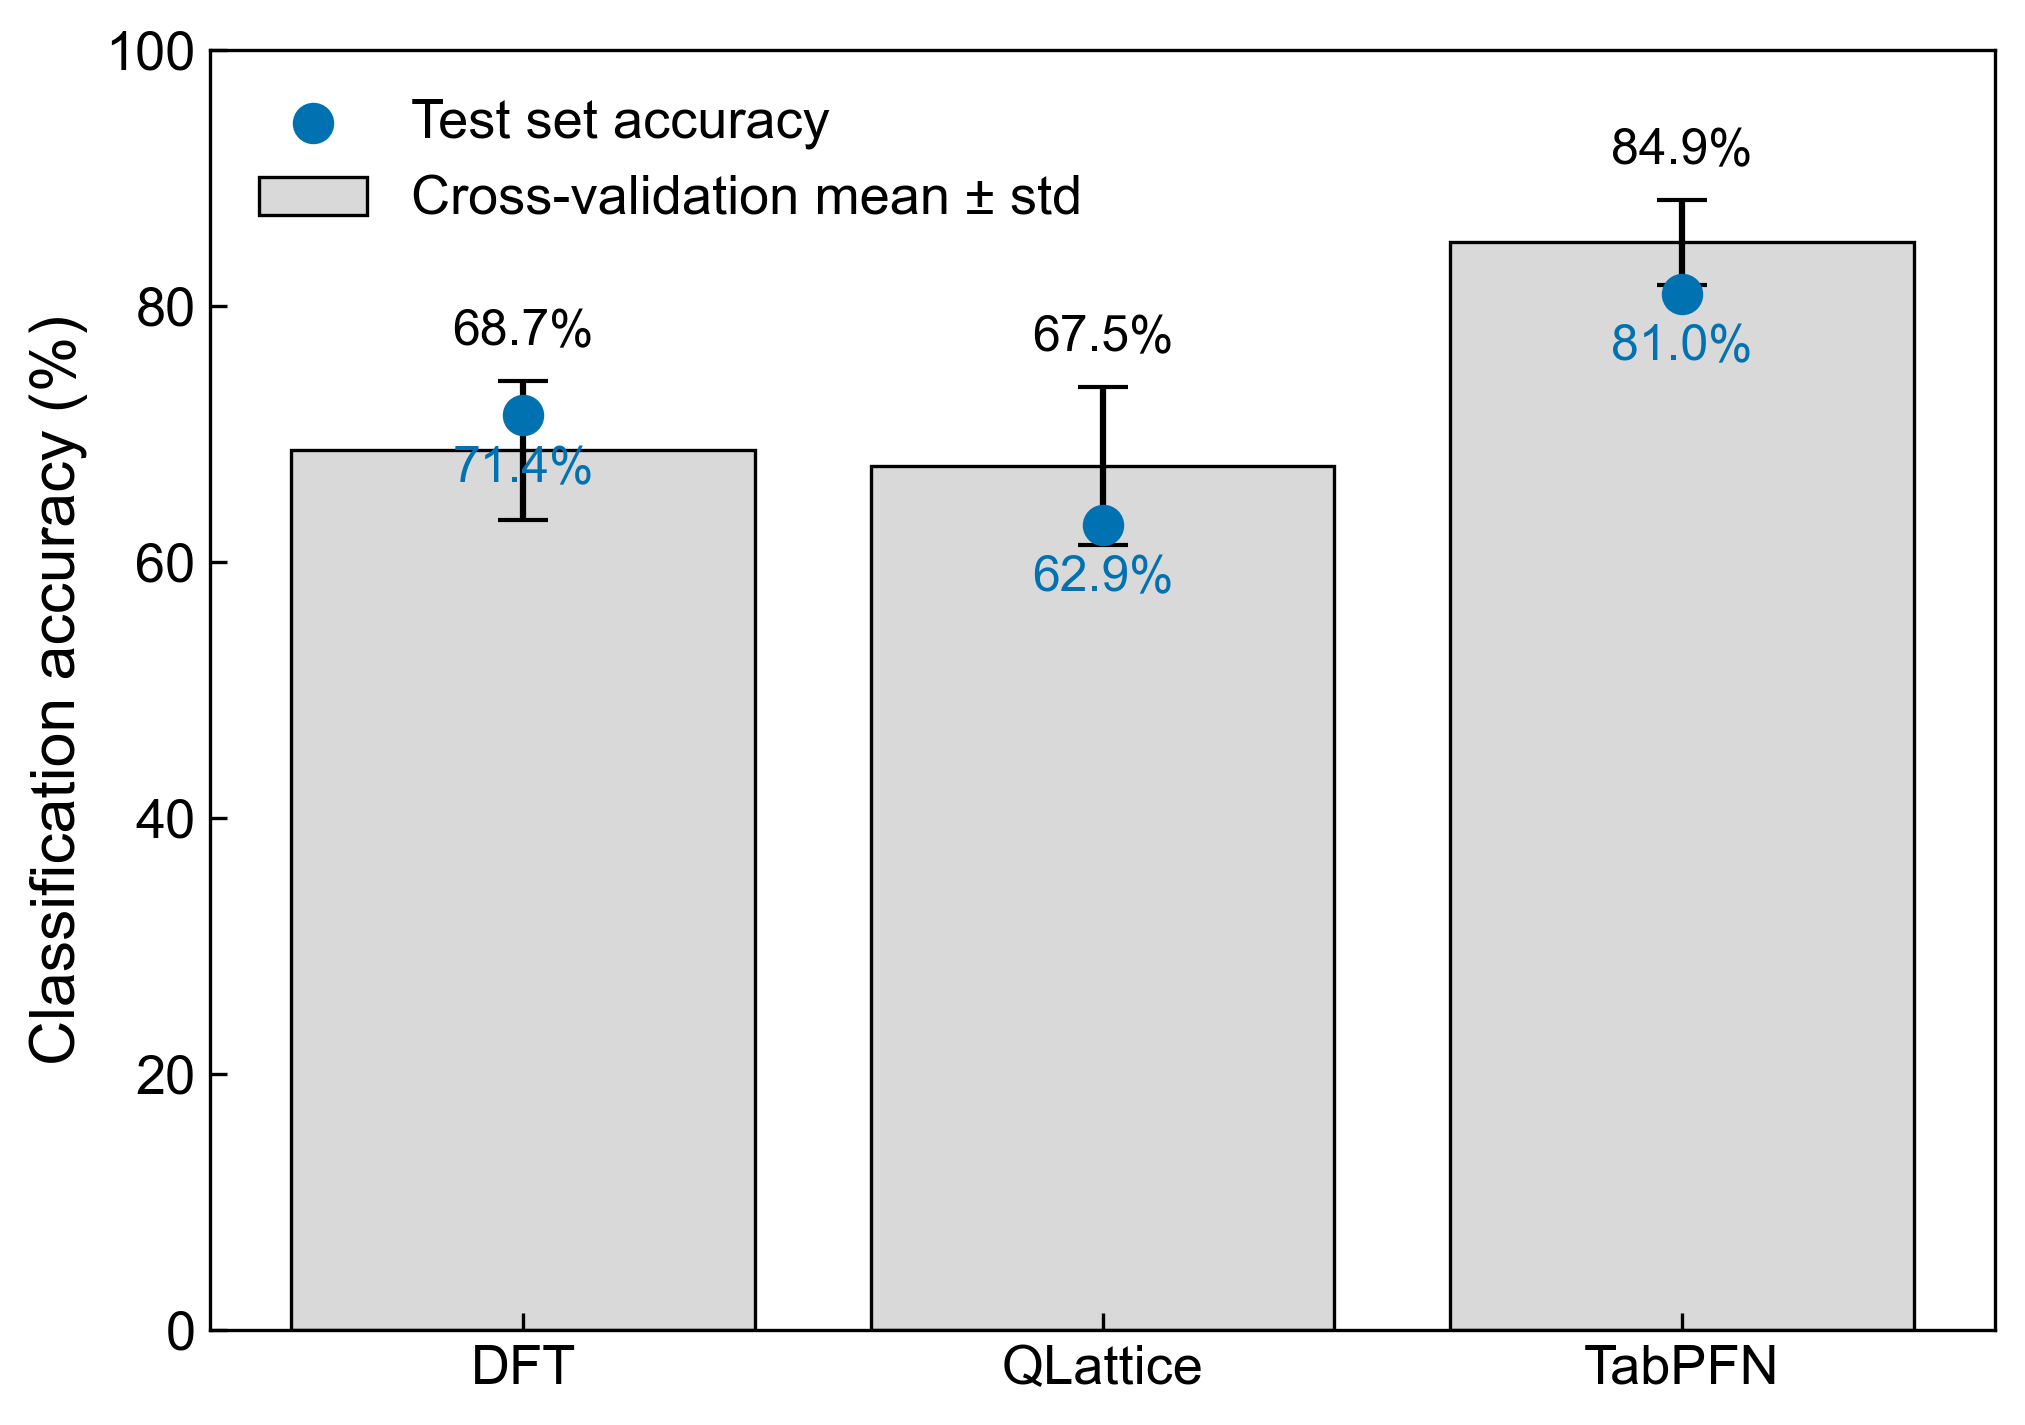

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Publication-quality matplotlib settings
# =====================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "mathtext.fontset": "stix",
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "mathtext.fontset": "dejavusans",
})

# =====================================================
# Model-level accuracy data
# =====================================================
models = ["DFT", "QLattice", "TabPFN"]

cv_mean = np.array([
    68.70,      # DFT
    67.47,      # QLattice
    84.94       # TabPFN
])

cv_std = np.array([
    5.44,       # DFT
    6.17,       # QLattice
    3.32        # TabPFN
])

test_accuracy = np.array([
    71.43,      # DFT
    62.90,      # QLattice
    80.95       # TabPFN
])

# =====================================================
# Plot
# =====================================================
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(models))

bars = ax.bar(
    x,
    cv_mean,
    yerr=cv_std,
    capsize=6,
    color="#D9D9D9",
    edgecolor="black",
    linewidth=0.8,
    label="Cross-validation mean ± std"
)

# Test accuracy markers
ax.scatter(
    x,
    test_accuracy,
    color="#0072B2",
    s=80,
    zorder=3,
    label="Test set accuracy"
)

# -----------------------------------------------------
# Annotation
# -----------------------------------------------------

for i in range(len(models)):
    ax.text(
        x[i],
        cv_mean[i] + cv_std[i] + 2,
        f"{cv_mean[i]:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12
    )

    ax.text(
        x[i],
        test_accuracy[i] - 6,
        f"{test_accuracy[i]:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        color="#0072B2"
    )

# =====================================================
# Axes & legend
# =====================================================
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 100)

ax.set_ylabel("Classification accuracy (%)")

ax.legend(frameon=False, loc="upper left", fontsize=13)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("model_accuracy_cv_vs_test.png")
plt.savefig("model_accuracy_cv_vs_test.pdf")
plt.savefig("model_accuracy_cv_vs_test.svg")
plt.show()
